# California SEN: county-scale 2D versus 3D validation

The statewide 2D graph uses OSM footprints selected from the union of the Interface, Intermix, and Influence Zone classes plus a three-mile buffer, whereas the county 3D graph uses LARIAC footprints. Raw node IDs therefore cannot be joined. This validation extracts the statewide buildings inside the transformed 3D county envelope, constructs a conservative one-to-one crosswalk from mutual-nearest footprint centroids within 5 m, and compares $F_{ij}=\max(F_{i\to j},F_{j\to i})$ only for building pairs present in both graphs. Cluster membership is not computed in this first validation step.

In [1]:
import os
import sys
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from shapely.geometry import box

cwd = Path.cwd().resolve()
PACKAGE_ROOT = next(
    path for path in [cwd, *cwd.parents]
    if (path / 'data').exists() and (path / 'src').exists()
    and (path / 'notebooks').exists()
)
sys.path.insert(0, str(PACKAGE_ROOT))

from src.analysis.carsen import (
    build_county_extent_crosswalk,
    build_shared_pair_comparison, build_statewide_components,
    build_statewide_ranked_incidence, fit_2d_fragility,
    logistic_5pl, pair_comparison_summary,
)
from src.viz.style import apply_style
from src.viz.carsen import (
    build_component_spatial_summary, load_california_context,
    plot_statewide_panel,
)

apply_style()
STATE_2D_RUN = Path(os.environ.get(
    'OPENVIEW_CA_2D_BVF_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/'
    'california_wui_all_3mi_osm_2d/full_california',
))
COUNTY_3D_RUN = Path(os.environ.get(
    'OPENVIEW_3D_BVF_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/'
    'lariac6_wui_all_2mi_bvf_3d_nf_cone85_nosolar_pads3m',
))
COUNTY_BUILDINGS = (
    PACKAGE_ROOT / 'data' / 'derived' / 'openview3d_lariac6_2mi'
    / 'county_buildings.parquet'
)
STATE_RUN_TAG = 'california_wui_all_3mi_osm_2d'
DERIVED = (
    PACKAGE_ROOT / 'data' / 'derived' / 'carsen_2d_vs_3d' / STATE_RUN_TAG
)
RESULTS = PACKAGE_ROOT / 'results' / 'carsen_2d_vs_3d' / STATE_RUN_TAG
FIGURES = PACKAGE_ROOT / 'figures' / 's2s_nc' /'main'/ STATE_RUN_TAG
for directory in (DERIVED, RESULTS, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

required_state_outputs = [
    STATE_2D_RUN / name for name in (
        'manifest.json', 'building_ids.parquet', 'building_edges.parquet'
    )
]
missing_state_outputs = [path for path in required_state_outputs if not path.exists()]
empty_state_outputs = [
    path for path in required_state_outputs if path.exists() and path.stat().st_size == 0
]
if missing_state_outputs or empty_state_outputs:
    raise RuntimeError(
        'The three-mile California OpenView run is not finalized. '
        f'Missing: {missing_state_outputs}; empty: {empty_state_outputs}'
    )

EXTENT_BUILDINGS = DERIVED / 'state_2d_buildings_in_county_3d_extent.parquet'
CROSSWALK = DERIVED / 'county_3d_to_state_2d_building_crosswalk.parquet'
PAIR_COMPARISON = DERIVED / 'county_matched_pair_F_2d_vs_3d.parquet'
CALIBRATION_DERIVED = (
    PACKAGE_ROOT / 'data' / 'derived' / 'carsen_2d_vs_3d'
)
FIRE_DOSE = CALIBRATION_DERIVED / 'fire_building_dose_2d.parquet'
FRAGILITY_TABLE = RESULTS / 'fragility_parameters_2d.csv'
STATE_COMPONENTS = DERIVED / 'statewide_components'
RANKED_INCIDENCE = STATE_COMPONENTS / 'california_top2_ranked_incidence.parquet'
SOURCE_PROJECT = PACKAGE_ROOT.parent
STATE_CENTROIDS = DERIVED / 'california_building_centroids_2d.parquet'
CA_BOUNDARY = SOURCE_PROJECT / 'data' / 'reference' / 'cb_2025_us_state_500k.zip'
CA_WUI_CLASSES = (
    SOURCE_PROJECT / 'data' / 'reference'
    / 'california_interface_intermix_influence_75m.parquet'
)
TOP2_EDGE_FLOOR_ALPHA = 0.75
# Primary statewide network: the midpoint-average threshold. The folder name
# predates its promotion from robustness check; 05_rsen reads the same folder.
STATE_COMPONENTS_CTOP2_ALPHA075 = (
    STATE_COMPONENTS / 'threshold_comparison'
    / 'midpoint_average_robustness'
)
STATE_COMPONENTS_CTOP2_ALPHA075_DIRECT = (
    STATE_COMPONENTS / 'absolute_p50_ctop2_alpha075'
)
STATE_COMPONENTS_CTOP2_ALPHA075_LOCAL = (
    STATE_COMPONENTS / 'threshold_comparison'
    / 'local_threshold_region_equivalent'
)
SPATIAL_DIR = STATE_COMPONENTS_CTOP2_ALPHA075 / 'spatial'


In [2]:
extent_path, crosswalk_path, extent_summary = build_county_extent_crosswalk(
    COUNTY_BUILDINGS, STATE_2D_RUN, EXTENT_BUILDINGS, CROSSWALK,
    maximum_centroid_distance_m=5.0,
)
extent_summary.to_csv(RESULTS / 'county_extent_crosswalk_summary.csv', index=False)
display(extent_summary.T.rename(columns={0: 'value'}))
print('2D county-extent extraction:', extent_path)
print('LARIAC–OSM crosswalk:', crosswalk_path)


,value
county_3d_buildings,1556752
state_2d_buildings_in_3d_extent,2121457
mutual_matches_within_distance,1402402
maximum_centroid_distance_m,5.0
share_of_3d_buildings_matched,0.900851
share_of_extent_2d_buildings_matched,0.661056
median_centroid_distance_m,1.248088
p95_centroid_distance_m,1.924441
county_extent_crs,EPSG:3310
county_extent_xmin,94292.811703


2D county-extent extraction: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/carsen_2d_vs_3d/california_wui_all_3mi_osm_2d/state_2d_buildings_in_county_3d_extent.parquet
LARIAC–OSM crosswalk: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/carsen_2d_vs_3d/california_wui_all_3mi_osm_2d/county_3d_to_state_2d_building_crosswalk.parquet


In [3]:
comparison_path = build_shared_pair_comparison(
    STATE_2D_RUN, COUNTY_3D_RUN, CROSSWALK, PAIR_COMPARISON,
)
correlation = pair_comparison_summary(comparison_path)
correlation.to_csv(RESULTS / 'county_matched_pair_F_correlation.csv', index=False)
display(correlation.T.rename(columns={0: 'value'}))
print('matched pair comparison:', comparison_path)


,value
shared_positive_pairs,1.233004e+07
pearson_r_raw,7.988868e-01
pearson_r_log10,8.648080e-01
log10_slope,1.337424e+00
log10_intercept,-5.810230e-01
median_F_2d,2.490542e-02
median_F_3d,1.433506e-03


matched pair comparison: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/carsen_2d_vs_3d/california_wui_all_3mi_osm_2d/county_matched_pair_F_2d_vs_3d.parquet


## Supplementary Figure S11 — fire-area matched pairs: 2 m spacing against 3D

Both models run on the same LARIAC footprints over Eaton and Palisades (perimeters + 800 m), so building pairs match exactly on `OBJECTID`. The 2D model samples each footprint side in equal pieces of at most 2 m, each with its own midpoint, kernel weight, and visibility ray. The 3D reference is the county run used throughout (near-field refinement, 85° cone, solar structures excluded, 3 m terrain pads). Pair coupling is $F_{ij} = \max(f_{i\to j}, f_{j\to i})$ in each model. The figure bins the 2D coupling logarithmically; points show the median 3D coupling in each bin and whiskers show the observed 2.5th–97.5th percentile range.


,2D model,shared positive pairs,pairs only in 2D,pairs only in 3D,Pearson r (log10),Spearman rho,residual SD (log10)
0,2 m spacing,853693,189785,204376,0.871,0.896,0.501


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/supplementary/FigS11_2d_2m_vs_3d_binned_95pct.png


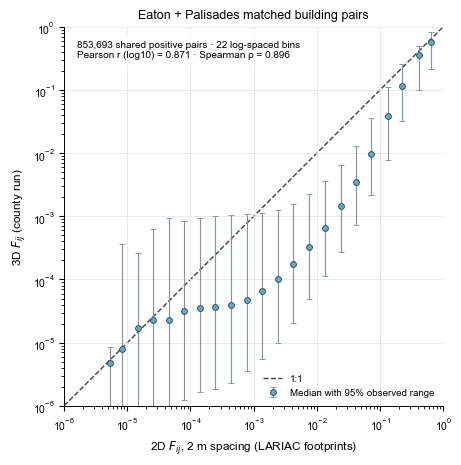

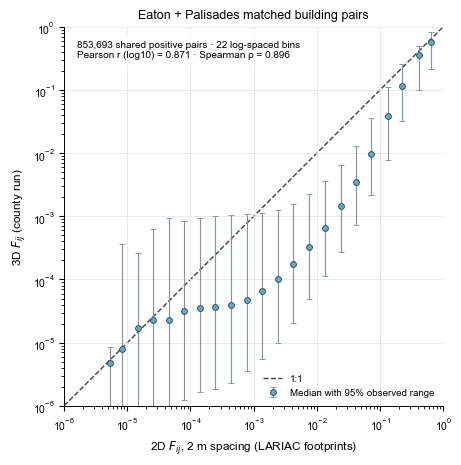

In [4]:
from scipy.stats import spearmanr

OPENVIEW_RESULTS = Path('/Users/adamswietek/Documents/PostDoc/openview/results')
FIRE_2D_RUN = Path(os.environ.get(
    'OPENVIEW_FIRE_2D_SEG2M_DIR',
    OPENVIEW_RESULTS / 'fires_eaton_palisades_800m_bvf_2d_lariac_seg2m',
))

fire_nodes = pd.read_parquet(
    FIRE_2D_RUN / 'building_ids.parquet', columns=['building_id'])
with duckdb.connect() as con:
    con.register('fire_nodes', fire_nodes)

    def fire_pairs(run_dir, column):
        edges = str(run_dir / 'building_edges.parquet').replace("'", "''")
        return con.execute(f"""
            SELECT building_i, building_j,
                   GREATEST(vf_i_to_j, vf_j_to_i) AS {column}
            FROM read_parquet('{edges}')
            WHERE building_i IN (SELECT building_id FROM fire_nodes)
              AND building_j IN (SELECT building_id FROM fire_nodes)
        """).fetchdf()

    pairs_2d = fire_pairs(FIRE_2D_RUN, 'F_2d')
    pairs_3d = fire_pairs(COUNTY_3D_RUN, 'F_3d')

merged = pairs_2d.merge(pairs_3d, on=['building_i', 'building_j'], how='outer')
matched_2m = merged.dropna().copy()
matched_2m = matched_2m[matched_2m.F_2d.gt(0) & matched_2m.F_3d.gt(0)]

log_x = np.log10(matched_2m.F_2d)
log_y = np.log10(matched_2m.F_3d)
resolution_table = pd.DataFrame([{
    '2D model': '2 m spacing',
    'shared positive pairs': len(matched_2m),
    'pairs only in 2D': int(merged.F_3d.isna().sum()),
    'pairs only in 3D': int(merged.F_2d.isna().sum()),
    'Pearson r (log10)': np.corrcoef(log_x, log_y)[0, 1],
    'Spearman rho': spearmanr(matched_2m.F_2d, matched_2m.F_3d).statistic,
    'residual SD (log10)': np.std(
        log_y - np.polyval(np.polyfit(log_x, log_y, 1), log_x)),
}])
resolution_table.to_csv(
    RESULTS / 'fire_matched_F_2d_2m_vs_3d.csv', index=False)
display(resolution_table.round(3))

limits = (1e-6, 1.0)
bin_edges = np.geomspace(*limits, 25)
bin_index = pd.cut(
    matched_2m.F_2d, bin_edges, labels=False,
    include_lowest=True, right=False,
)
binned = (matched_2m.assign(x_bin=bin_index)
          .dropna(subset=['x_bin'])
          .groupby('x_bin', observed=True)
          .agg(F_2d=('F_2d', 'median'),
               F_3d_median=('F_3d', 'median'),
               F_3d_p025=('F_3d', lambda values: values.quantile(.025)),
               F_3d_p975=('F_3d', lambda values: values.quantile(.975)),
               pairs=('F_3d', 'size'))
          .reset_index())
binned['bin_left'] = bin_edges[binned.x_bin.astype(int)]
binned['bin_right'] = bin_edges[binned.x_bin.astype(int) + 1]
binned.to_csv(
    RESULTS / 'fire_matched_F_2d_2m_vs_3d_binned_95pct.csv', index=False)

fig, ax = plt.subplots(figsize=(5.3, 4.7))
yerr = np.vstack([
    binned.F_3d_median - binned.F_3d_p025,
    binned.F_3d_p975 - binned.F_3d_median,
])
ax.errorbar(
    binned.F_2d, binned.F_3d_median, yerr=yerr,
    fmt='o', ms=4.2, color='#2E617F', mfc='#6FA6BF', mec='#244C63',
    mew=.65, ecolor='#7796A5', elinewidth=.8, capsize=2.0, capthick=.8,
    label='Median with 95% observed range', zorder=3,
)
ax.plot(limits, limits, color='.25', lw=1, ls='--', label='1:1', zorder=1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set(
    xlim=limits, ylim=limits, aspect='equal',
    xlabel=r'2D $F_{ij}$, 2 m spacing (LARIAC footprints)',
    ylabel=r'3D $F_{ij}$ (county run)',
    title='Eaton + Palisades matched building pairs',
)
stats = resolution_table.iloc[0]
ax.text(
    .035, .965,
    f"{len(matched_2m):,} shared positive pairs · {len(binned)} log-spaced bins\n"
    f"Pearson r (log10) = {stats['Pearson r (log10)']:.3f} · "
    f"Spearman ρ = {stats['Spearman rho']:.3f}",
    transform=ax.transAxes, ha='left', va='top', fontsize=7.2,
    bbox=dict(facecolor='white', edgecolor='none', alpha=.88),
)
ax.grid(which='major', color='#E3E5E6', lw=.55)
ax.legend(frameon=False, loc='lower right', fontsize=7)
fig.tight_layout()
supplementary_figures = PACKAGE_ROOT / 'figures' / 'supplementary'
supplementary_figures.mkdir(parents=True, exist_ok=True)
stem = supplementary_figures / 'FigS11_2d_2m_vs_3d_binned_95pct'
fig.savefig(stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig.savefig(stem.with_suffix('.png'), dpi=400, bbox_inches='tight', facecolor='white')
print('saved', stem.with_suffix('.png'))
fig


## Statewide clustering threshold: midpoint average of the 2D and 3D calibrations

Two calibrations give a 2D threshold. The independent Eaton–Palisades 2D fire-dose curve gives the direct 2D absolute-$P=.50$ midpoint, $F^*_{2D}=0.2556$. The pooled 3D P50 midpoint, inverse-mapped onto the 2D scale with the matched-pair fit restricted to the threshold region, gives $F^*_{2D}=0.1653$. The primary statewide threshold is their arithmetic mean, $F^*_{2D}=0.2104$. The statewide graph is also rebuilt at each endpoint as a sensitivity check.


,metric,model,fire,n,p_min,p_max,k,hill,asymmetry,asymptotic_f50,absolute_p50,brier,log_loss,parameter_at_bound
0,dose_sum,5PL,EATON,14200,0.024716,0.966586,0.299870,2.646366,0.799934,0.265610,0.267615,0.118840,0.383913,False
1,dose_sum,5PL,PALISADES,10103,0.034246,0.983808,0.534867,4.206323,0.205438,0.241817,0.236327,0.133007,0.418450,False
2,dose_sum,5PL,POOLED,24303,0.029943,0.972098,0.413133,3.152647,0.405902,0.256096,0.255567,0.125705,0.402286,False


,definition,F_2d,role
0,Direct 2D absolute-P50 midpoint,0.255567,sensitivity threshold (upper)
1,Locally inverse-mapped 3D P50 midpoint,0.165264,sensitivity threshold (lower)
2,Mean of direct and locally inverse-mapped midp...,0.210415,primary statewide SEN threshold


Pooled 5PL absolute P=.50 dose: 0.255566729
Local 3D-equivalent threshold: 0.165263731
Primary midpoint-average threshold: 0.210415230


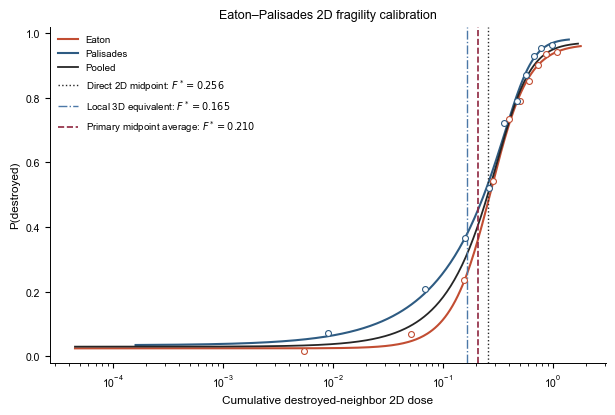

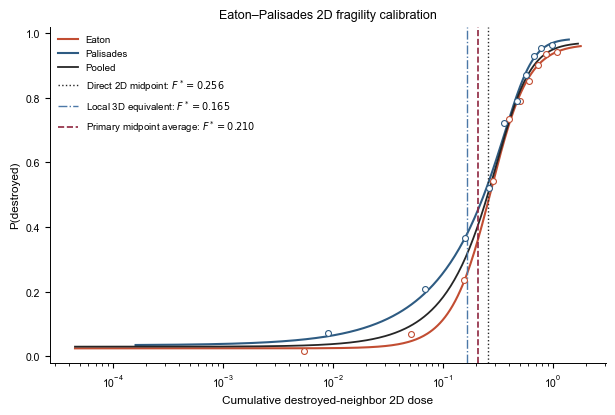

In [5]:
# Resolve independently so a stale kernel cannot retain the former run-specific path.
FIRE_DOSE = (
    PACKAGE_ROOT / 'data' / 'derived' / 'carsen_2d_vs_3d'
    / 'fire_building_dose_2d.parquet'
)
if not FIRE_DOSE.exists():
    raise FileNotFoundError(
        'The fixed Eaton–Palisades 2D fire-dose cache is missing: '
        f'{FIRE_DOSE}'
    )
dose_path = FIRE_DOSE
fragility_table, fragility_fits = fit_2d_fragility(dose_path)
fragility_table.to_csv(FRAGILITY_TABLE, index=False)
pooled_fit = fragility_fits['POOLED']
F_2D_ABSOLUTE_P50 = float(pooled_fit['absolute_p50'])
if not np.isfinite(F_2D_ABSOLUTE_P50):
    raise RuntimeError('Pooled 2D fit does not cross absolute P=.50')
if pooled_fit['parameter_at_bound']:
    raise RuntimeError('Pooled 2D fragility fit reached a parameter bound')

# The OpenView 3D P50 midpoint is 0.055429. Its local matched-pair inverse on
# the 2D scale is 0.165264. The primary statewide threshold averages that
# translated midpoint with the independently fitted 2D midpoint; neither is
# hand-picked, and both endpoints are kept as sensitivity checks.
F_3D_ABSOLUTE_P50 = 0.05542927333272378
F_2D_LOCAL_EQUIVALENT = 0.16526373070
F_2D_NETWORK_THRESHOLD = float(np.mean([
    F_2D_ABSOLUTE_P50, F_2D_LOCAL_EQUIVALENT,
]))
threshold_definitions = pd.DataFrame([
    {
        'definition': 'Direct 2D absolute-P50 midpoint',
        'F_2d': F_2D_ABSOLUTE_P50,
        'role': 'sensitivity threshold (upper)',
    },
    {
        'definition': 'Locally inverse-mapped 3D P50 midpoint',
        'F_2d': F_2D_LOCAL_EQUIVALENT,
        'role': 'sensitivity threshold (lower)',
    },
    {
        'definition': 'Mean of direct and locally inverse-mapped midpoints',
        'F_2d': F_2D_NETWORK_THRESHOLD,
        'role': 'primary statewide SEN threshold',
    },
])
threshold_definitions.to_csv(
    RESULTS / 'california_2d_sen_threshold_definitions.csv', index=False,
)
display(fragility_table.round(6))
display(threshold_definitions.round(6))
print(f'Pooled 5PL absolute P=.50 dose: {F_2D_ABSOLUTE_P50:.9f}')
print(f'Local 3D-equivalent threshold: {F_2D_LOCAL_EQUIVALENT:.9f}')
print(f'Primary midpoint-average threshold: {F_2D_NETWORK_THRESHOLD:.9f}')

dose = pd.read_parquet(dose_path)
colors = {'EATON': '#C24D32', 'PALISADES': '#2E5B82'}
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for fire in ('EATON', 'PALISADES'):
    sample = dose[dose.fire.eq(fire) & dose.dose_sum.gt(0)].copy()
    sample['bin'] = pd.qcut(sample.dose_sum, 10, duplicates='drop')
    binned = sample.groupby('bin', observed=True).agg(
        dose=('dose_sum', lambda values: np.exp(np.log(values).mean())),
        probability=('is_destroyed', 'mean'),
    )
    fit = fragility_fits[fire]
    grid = np.geomspace(sample.dose_sum.min(), sample.dose_sum.quantile(.999), 400)
    ax.plot(grid, fit['fn'](grid, *fit['parameters']), color=colors[fire],
            label=fire.title())
    ax.scatter(binned.dose, binned.probability, s=18, facecolor='white',
               edgecolor=colors[fire], linewidth=.8, zorder=3)
pooled_positive = dose.loc[dose.dose_sum.gt(0), 'dose_sum']
pooled_grid = np.geomspace(
    pooled_positive.min(), pooled_positive.quantile(.999), 400,
)
ax.plot(pooled_grid, pooled_fit['fn'](pooled_grid, *pooled_fit['parameters']),
        color='.15', lw=1.3, label='Pooled')
ax.axvline(F_2D_ABSOLUTE_P50, color='.15', lw=1, ls=':',
           label=fr'Direct 2D midpoint: $F^*={F_2D_ABSOLUTE_P50:.3f}$')
ax.axvline(F_2D_LOCAL_EQUIVALENT, color='#4C78A8', lw=1, ls='-.',
           label=fr'Local 3D equivalent: $F^*={F_2D_LOCAL_EQUIVALENT:.3f}$')
ax.axvline(F_2D_NETWORK_THRESHOLD, color='#8F263F', lw=1.2, ls='--',
           label=fr'Primary midpoint average: $F^*={F_2D_NETWORK_THRESHOLD:.3f}$')
ax.set(xscale='log', ylim=(-.02, 1.02), xlabel='Cumulative destroyed-neighbor 2D dose',
       ylabel='P(destroyed)', title='Eaton–Palisades 2D fragility calibration')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
fragility_stem = FIGURES / 'carsen_2d_fragility_absolute_p50'
fig.savefig(fragility_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig.savefig(fragility_stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white')
fig


## California cumulative Top-2 network

The primary statewide network uses the midpoint average of the direct 2D and inverse-mapped 3D P50 midpoints, $F^*_{2D}=0.2104$. **Cumulative Top-2** requires two ranked incident neighbors whose scores sum to at least $F^*$. Following `05_rsen.ipynb`, retained links must connect two qualifying endpoints and each individual coupling must reach $\alpha F^*$, with $\alpha=0.75$. Components are labeled over every statewide graph node, so buildings outside the qualifying network remain explicit singletons. The complete graph is also rebuilt at both endpoints, $F^*_{2D}=0.1653$ and $0.2556$, as sensitivity checks.


In [6]:
ranked_path = build_statewide_ranked_incidence(
    STATE_2D_RUN, RANKED_INCIDENCE, maximum_rank=2,
)
top2_paths = build_statewide_components(
    STATE_2D_RUN, STATE_COMPONENTS_CTOP2_ALPHA075,
    F_2D_NETWORK_THRESHOLD, 'top2', ranked_path=ranked_path, n_neighbors=2,
    edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA,
)
local_top2_paths = build_statewide_components(
    STATE_2D_RUN, STATE_COMPONENTS_CTOP2_ALPHA075_LOCAL,
    F_2D_LOCAL_EQUIVALENT, 'top2', ranked_path=ranked_path, n_neighbors=2,
    edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA,
)
direct_top2_paths = build_statewide_components(
    STATE_2D_RUN, STATE_COMPONENTS_CTOP2_ALPHA075_DIRECT,
    F_2D_ABSOLUTE_P50, 'top2', ranked_path=ranked_path, n_neighbors=2,
    edge_floor_fraction=TOP2_EDGE_FLOOR_ALPHA,
)

statewide_summary = pd.read_csv(top2_paths['summary'])
local_statewide_summary = pd.read_csv(local_top2_paths['summary'])
direct_statewide_summary = pd.read_csv(direct_top2_paths['summary'])
threshold_robustness_summary = pd.concat([
    statewide_summary.assign(
        threshold_definition='Mean of direct and inverse-mapped midpoints (primary)'),
    local_statewide_summary.assign(
        threshold_definition='Local 3D-equivalent (sensitivity)'),
    direct_statewide_summary.assign(
        threshold_definition='Direct 2D absolute-P50 midpoint (sensitivity)'),
], ignore_index=True)
threshold_robustness_summary['largest_component_relative_to_primary'] = (
    threshold_robustness_summary.largest_component
    / float(statewide_summary.largest_component.iloc[0])
)
threshold_robustness_summary['active_edges_relative_to_primary'] = (
    threshold_robustness_summary.active_edges
    / float(statewide_summary.active_edges.iloc[0])
)
threshold_robustness_summary.to_csv(
    RESULTS / 'california_ctop2_alpha075_threshold_robustness.csv', index=False,
)
display(threshold_robustness_summary)
print('Primary midpoint-average assignments:', top2_paths['assignments'])
print('Local 3D-equivalent sensitivity assignments:', local_top2_paths['assignments'])
print('Direct 2D-midpoint sensitivity assignments:', direct_top2_paths['assignments'])


,region,method,threshold,neighbors_summed,edge_floor_fraction,individual_edge_floor,nodes,candidate_pairs,qualifying_buildings,active_edges,all_node_components,connected_components,largest_component,threshold_definition,largest_component_relative_to_primary,active_edges_relative_to_primary
0,California WUI sample,top2,0.210415,2,0.75,0.157811,7204007,81350243,6388092,4222789,3072562,1180325,720,Mean of direct and inverse-mapped midpoints (p...,1.000000,1.000000
1,California WUI sample,top2,0.165264,2,0.75,0.123948,7204007,81350243,6770471,5911960,1686543,781139,4819,Local 3D-equivalent (sensitivity),6.693056,1.400013
2,California WUI sample,top2,0.255567,2,0.75,0.191675,7204007,81350243,5713922,2808855,4416161,1223216,164,Direct 2D absolute-P50 midpoint (sensitivity),0.227778,0.665166


Primary midpoint-average assignments: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/carsen_2d_vs_3d/california_wui_all_3mi_osm_2d/statewide_components/threshold_comparison/midpoint_average_robustness/california_top2_assignments.parquet
Local 3D-equivalent sensitivity assignments: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/carsen_2d_vs_3d/california_wui_all_3mi_osm_2d/statewide_components/threshold_comparison/local_threshold_region_equivalent/california_top2_assignments.parquet
Direct 2D-midpoint sensitivity assignments: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/carsen_2d_vs_3d/california_wui_all_3mi_osm_2d/statewide_components/absolute_p50_ctop2_alpha075/california_top2_assignments.parquet


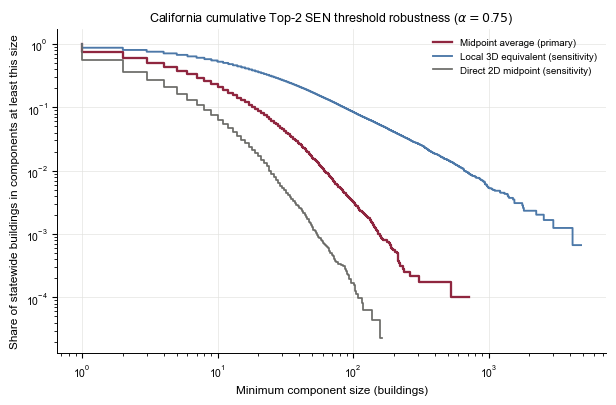

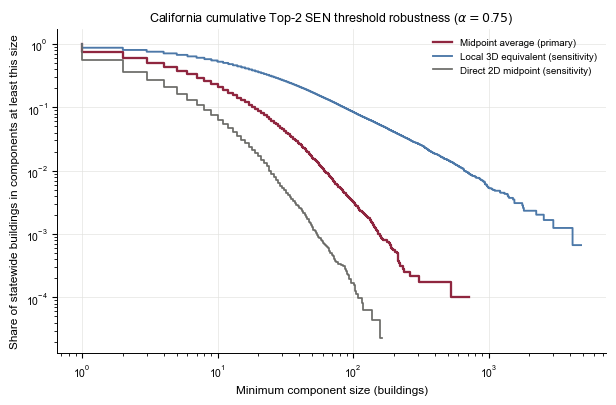

In [7]:
fig, ax = plt.subplots(figsize=(6.2, 4.1))
robustness_curves = [
    ('Midpoint average (primary)', top2_paths, '#8F263F', 1.65),
    ('Local 3D equivalent (sensitivity)', local_top2_paths, '#4C78A8', 1.35),
    ('Direct 2D midpoint (sensitivity)', direct_top2_paths, '#6B6B67', 1.25),
]
for label, paths, color, linewidth in robustness_curves:
    curve = pd.read_csv(paths['sizes']).sort_values(
        'component_size', ascending=False,
    )
    curve['buildings_at_least'] = curve.buildings.cumsum()
    curve['building_share'] = curve.buildings_at_least / curve.buildings.sum()
    ax.step(
        curve.component_size, curve.building_share, where='post',
        color=color, lw=linewidth, label=label,
    )
ax.set(
    xscale='log', yscale='log',
    xlabel='Minimum component size (buildings)',
    ylabel='Share of statewide buildings in components at least this size',
    title=(r'California cumulative Top-2 SEN threshold robustness '
           rf'($\alpha={TOP2_EDGE_FLOOR_ALPHA:g}$)'),
)
ax.grid(which='major', color='#E1E1DE', linewidth=.45)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
size_stem = FIGURES / 'carsen_california_ctop2_alpha075_threshold_robustness'
fig.savefig(size_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig.savefig(size_stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white')
fig


## Statewide cumulative Top-2 map

The map uses the three-mile combined-WUI statewide graph and cumulative Top-2 clustering at the primary midpoint-average threshold, $F^*_{2D}=0.2104$, with $\alpha=0.75$. Interface-connected component centroids are binned spatially; each occupied hexagon is colored by the largest component centered there on a logarithmic cubehelix scale. Influence, Intermix, and Interface boundaries remain visible as geographic context.


In [8]:
def build_state_centroids(run_dir, output_path):
    """Build a run-specific, length-weighted centroid cache for map joins."""
    if output_path.exists():
        return output_path
    patch_files = list((run_dir / 'patches').glob('*.parquet'))
    if not patch_files:
        raise FileNotFoundError(f"No patch parquet files under {run_dir / 'patches'}")
    partial = output_path.with_suffix(output_path.suffix + '.partial')
    partial.unlink(missing_ok=True)
    patch_glob = str(run_dir / 'patches' / '*.parquet').replace("'", "''")
    destination = str(partial).replace("'", "''")
    with duckdb.connect() as con:
        con.execute('SET threads=4')
        con.execute('SET preserve_insertion_order=false')
        con.execute(f"""
            COPY (
                SELECT building_id,
                       SUM(x_m * length_m) / SUM(length_m) AS x,
                       SUM(y_m * length_m) / SUM(length_m) AS y
                FROM read_parquet('{patch_glob}')
                GROUP BY building_id
            ) TO '{destination}' (FORMAT PARQUET, COMPRESSION ZSTD)
        """)
    partial.replace(output_path)
    return output_path

build_state_centroids(STATE_2D_RUN, STATE_CENTROIDS)
boundary, wui_classes = load_california_context(CA_BOUNDARY, CA_WUI_CLASSES)
assignment_paths = {'top2': top2_paths['assignments']}
component_summary_paths = {}
for method, assignment_path in assignment_paths.items():
    component_summary_paths[method] = build_component_spatial_summary(
        assignment_path, STATE_CENTROIDS, wui_classes,
        SPATIAL_DIR / f'california_{method}_component_spatial_summary.parquet',
    )
pd.DataFrame({'method': component_summary_paths.keys(), 'component_summary': component_summary_paths.values()})


,method,component_summary
0,top2,/Users/adamswietek/Documents/PostDoc/wildfire/...


In [9]:
# Network-size classes shared by the statewide maps below: quantiles of the
# per-hexagon maximum SEN size on a 1,000-hexagon grid (no figure drawn here).
clusters = pd.read_parquet(
    component_summary_paths['top2'], columns=['x', 'y', 'component_size'],
)
fig_hex, ax_hex = plt.subplots()
hex_max = ax_hex.hexbin(
    clusters.x, clusters.y, C=clusters.component_size,
    reduce_C_function=np.max, gridsize=1_000, mincnt=1,
)
plt.close(fig_hex)
quantile_bounds = np.unique(np.rint(np.quantile(
    hex_max.get_array().compressed(), np.linspace(0, 1, 8),
)).astype(int))
max_size_norm = mpl.colors.BoundaryNorm(
    quantile_bounds, plt.colormaps['RdYlBu_r'].N, clip=True,
)
print('network-size class bounds:', ', '.join(f'{value:,}' for value in quantile_bounds))

network-size class bounds: 2, 3, 4, 8, 14, 24, 720


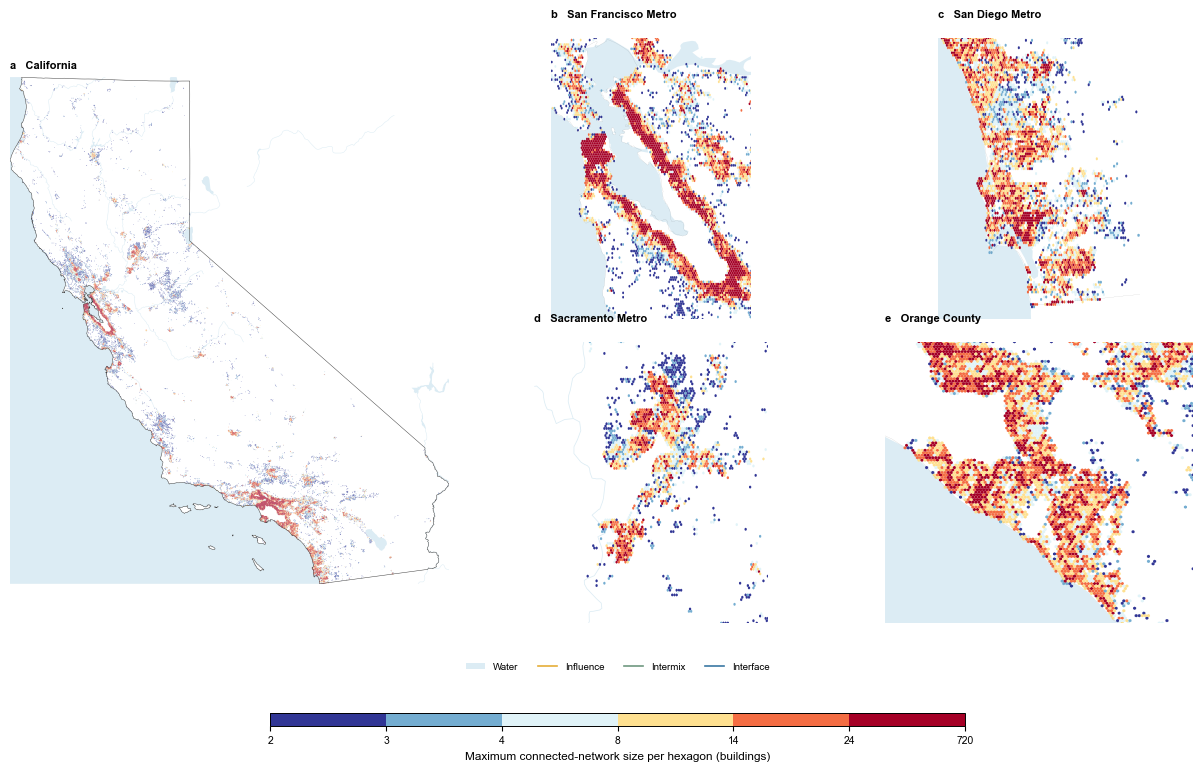

In [10]:
from matplotlib.patches import Patch
from pyproj import Transformer

METRO_BOUNDS = {
    'San Francisco Metro': (-122.65, 37.15, -121.75, 38.15),
    'San Diego Metro': (-117.40, 32.50, -116.80, 33.20),
    'Sacramento Metro': (-121.75, 38.20, -120.90, 39.00),
    'Orange County': (-118.15, 33.38, -117.40, 33.95),
}
METRO_WUI_COLORS = {
    'Influence': '#E5AE38',
    'Intermix': '#6F9880',
    'Interface': '#3B78A3',
}
metro_wui = {
    name: frame.to_crs(3857)
    for name, frame in wui_classes.items()
    if name in METRO_WUI_COLORS
}
metro_boundary = boundary.to_crs(3857)
to_web_mercator = Transformer.from_crs(
    boundary.crs, 3857, always_xy=True,
)
WATER_COLOR = '#DCECF4'
HYDRO_DIR = SOURCE_PROJECT / 'data' / 'reference' / 'natural_earth_hydro'
HYDRO_BBOX = (-125, 32, -113, 43)
metro_ocean = gpd.read_file(
    HYDRO_DIR / 'ne_10m_ocean.shp', bbox=HYDRO_BBOX,
).to_crs(3857)
metro_lakes = gpd.read_file(
    HYDRO_DIR / 'ne_10m_lakes.shp', bbox=HYDRO_BBOX,
).to_crs(3857)
metro_rivers = gpd.read_file(
    HYDRO_DIR / 'ne_10m_rivers_lake_centerlines.shp', bbox=HYDRO_BBOX,
).to_crs(3857)

fig_regions = plt.figure(figsize=(12.4, 7.6))
region_grid = fig_regions.add_gridspec(
    2, 3, width_ratios=(1.18, 1, 1), hspace=.08, wspace=.04,
)
state_ax = fig_regions.add_subplot(region_grid[:, 0])
metro_axes = np.array([
    [fig_regions.add_subplot(region_grid[0, 1]),
     fig_regions.add_subplot(region_grid[0, 2])],
    [fig_regions.add_subplot(region_grid[1, 1]),
     fig_regions.add_subplot(region_grid[1, 2])],
])

state_xmin, state_ymin, state_xmax, state_ymax = boundary.total_bounds
state_window = gpd.GeoSeries(
    [box(state_xmin, state_ymin, state_xmax, state_ymax)],
    crs=boundary.crs,
)
state_ocean = gpd.clip(metro_ocean.to_crs(boundary.crs), state_window)
state_lakes = gpd.clip(metro_lakes.to_crs(boundary.crs), state_window)
state_rivers = gpd.clip(metro_rivers.to_crs(boundary.crs), state_window)
state_ocean.plot(ax=state_ax, color=WATER_COLOR, linewidth=0, zorder=0)
state_lakes.plot(ax=state_ax, color=WATER_COLOR, linewidth=0, zorder=0)
state_rivers.plot(ax=state_ax, color=WATER_COLOR, linewidth=.35, zorder=1)
state_hex = state_ax.hexbin(
    clusters.x, clusters.y, C=clusters.component_size,
    reduce_C_function=np.max, gridsize=1_000, mincnt=1,
    cmap='RdYlBu_r', norm=max_size_norm, linewidths=0,
    rasterized=True, zorder=2,
)
boundary.boundary.plot(
    ax=state_ax, color='#404040', linewidth=.35, zorder=6,
)
state_ax.set(
    xlim=(state_xmin, state_xmax), ylim=(state_ymin, state_ymax),
    aspect='equal',
)
state_ax.axis('off')
state_ax.set_title(
    'a   California', loc='left', fontsize=8, fontweight='bold',
)

for panel_label, ax, (name, lon_lat_bounds) in zip(
    'bcde', metro_axes.flat, METRO_BOUNDS.items(),
):
    state_window = gpd.GeoSeries(
        [box(*lon_lat_bounds)], crs='EPSG:4326',
    ).to_crs(boundary.crs)
    sxmin, symin, sxmax, symax = state_window.total_bounds
    metro_clusters = clusters.loc[
        clusters.x.between(sxmin, sxmax)
        & clusters.y.between(symin, symax)
    ]
    metro_x, metro_y = to_web_mercator.transform(
        metro_clusters.x.to_numpy(), metro_clusters.y.to_numpy(),
    )
    metro_window = gpd.GeoSeries(
        [box(*lon_lat_bounds)], crs='EPSG:4326',
    ).to_crs(3857)
    xmin, ymin, xmax, ymax = metro_window.total_bounds
    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax))
    local_ocean = gpd.clip(metro_ocean, metro_window)
    local_lakes = gpd.clip(metro_lakes, metro_window)
    local_rivers = gpd.clip(metro_rivers, metro_window)
    if not local_ocean.empty:
        local_ocean.plot(ax=ax, color=WATER_COLOR, linewidth=0, zorder=0)
    if not local_lakes.empty:
        local_lakes.plot(ax=ax, color=WATER_COLOR, linewidth=0, zorder=0)
    if not local_rivers.empty:
        local_rivers.plot(ax=ax, color=WATER_COLOR, linewidth=.55, zorder=1)
    metro_hex = ax.hexbin(
        metro_x, metro_y,
        C=metro_clusters.component_size, reduce_C_function=np.max,
        gridsize=max(100, round((xmax - xmin) / 900)), mincnt=1,
        extent=(xmin, xmax, ymin, ymax), cmap='RdYlBu_r', norm=max_size_norm,
        linewidths=0, rasterized=True,
    )
    # for wui_name, color in METRO_WUI_COLORS.items():
    #     local_wui = metro_wui[wui_name].cx[xmin:xmax, ymin:ymax]
    #     if not local_wui.empty:
    #         local_wui.boundary.plot(
    #             ax=ax, color='white', linewidth=1.15, zorder=4,
    #         )
    #         local_wui.boundary.plot(
    #             ax=ax, color=color, linewidth=.50, zorder=5,
    #         )
    metro_boundary.boundary.plot(ax=ax, color='#404040', linewidth=.045)
    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), aspect='equal')
    ax.axis('off')
    ax.set_title(
        f'{panel_label}   {name}', loc='left',
        fontsize=8, fontweight='bold',
    )

fig_regions.subplots_adjust(
    left=.01, right=.99, top=.95, bottom=.18, hspace=.08, wspace=.04,
)
region_cbar_ax = fig_regions.add_axes([.22, .045, .56, .016])
region_cbar = fig_regions.colorbar(
    state_hex, cax=region_cbar_ax, orientation='horizontal',
    ticks=quantile_bounds,
)
region_cbar.set_ticklabels([f'{value:d}' for value in quantile_bounds])
region_cbar.set_label('Maximum connected-network size per hexagon (buildings)')
fig_regions.legend(
    handles=[
        Patch(facecolor=WATER_COLOR, edgecolor='none', label='Water'),
        *[Line2D([], [], color=color, linewidth=1.2, label=name)
          for name, color in METRO_WUI_COLORS.items()],
    ],
    loc='lower center', bbox_to_anchor=(.5, .105), ncol=4,
    frameon=False, fontsize=7,
)
# fig_regions


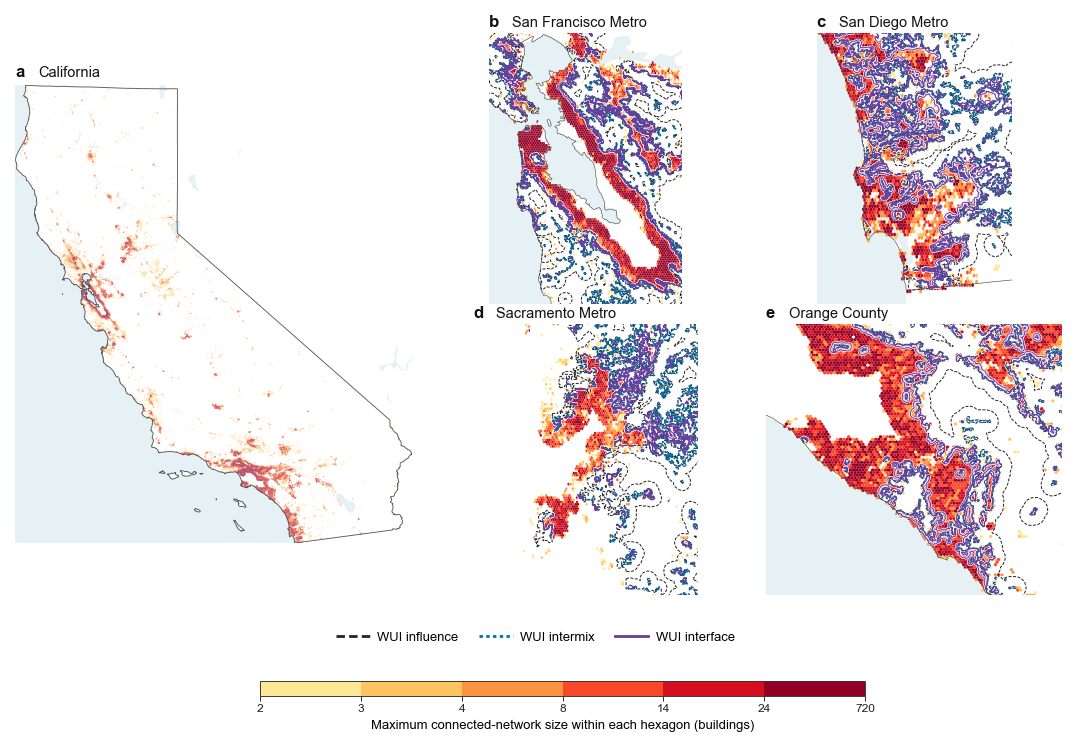

Saved SVG: /Users/adamswietek/Documents/PostDoc/wildfire/outputs/figures/connected_networks_california_metros.svg
Saved PDF: /Users/adamswietek/Documents/PostDoc/wildfire/outputs/figures/connected_networks_california_metros.pdf
Saved PNG: /Users/adamswietek/Documents/PostDoc/wildfire/outputs/figures/connected_networks_california_metros.png


In [11]:
# ============================================================
# California connected-building networks and WUI classes
# Publication-ready regional figure
#
# Required existing objects:
#   boundary        California boundary GeoDataFrame
#   clusters        Table with x, y, and component_size
#   wui_classes     Dictionary of WUI GeoDataFrames
#   quantile_bounds Existing network-size class boundaries
#   SOURCE_PROJECT  pathlib.Path for the project
#
# Important:
#   - boundary geometry column: "geometry"
#   - WUI geometry column: "Shape"
# ============================================================

from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from pyproj import Transformer
from shapely.geometry import box


# ------------------------------------------------------------
# 1. Figure typography and export settings
# ------------------------------------------------------------

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans",
    ],
    "font.size": 6.5,
    "axes.titlesize": 7,
    "axes.labelsize": 6.5,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6.25,

    # Keep text editable in vector exports.
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",

    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})


# ------------------------------------------------------------
# 2. Geographic configuration
# ------------------------------------------------------------

METRO_BOUNDS = {
    "San Francisco Metro": (
        -122.65, 37.15,
        -121.75, 38.15,
    ),
    "San Diego Metro": (
        -117.40, 32.50,
        -116.80, 33.20,
    ),
    "Sacramento Metro": (
        -121.75, 38.20,
        -120.90, 39.00,
    ),
    "Orange County": (
        -118.15, 33.38,
        -117.40, 33.95,
    ),
}

WEB_MERCATOR = "EPSG:3857"

if boundary.crs is None:
    raise ValueError("boundary must have a defined CRS.")

required_cluster_columns = {
    "x",
    "y",
    "component_size",
}

missing_cluster_columns = (
    required_cluster_columns.difference(clusters.columns)
)

if missing_cluster_columns:
    raise ValueError(
        "clusters is missing required columns: "
        f"{sorted(missing_cluster_columns)}"
    )


# ------------------------------------------------------------
# 3. Visual hierarchy
# ------------------------------------------------------------

LAND_COLOR = "#FFFFFF"
WATER_COLOR = "#E6F1F6"
STATE_OUTLINE_COLOR = "#565656"

# Network-size bins from the existing analysis.
NETWORK_BOUNDS = np.asarray(
    quantile_bounds,
    dtype=float,
).copy()

# Make sure the final class includes the observed maximum.
observed_max = float(
    np.nanmax(clusters["component_size"])
)

NETWORK_BOUNDS[-1] = max(
    NETWORK_BOUNDS[-1],
    np.ceil(observed_max),
)

N_NETWORK_CLASSES = len(NETWORK_BOUNDS) - 1

if N_NETWORK_CLASSES < 2:
    raise ValueError(
        "quantile_bounds must define at least two intervals."
    )

# Sequential light-yellow to dark-red scale.
# Small networks remain contextual; large networks dominate.
base_network_cmap = mpl.colormaps["YlOrRd"]

NETWORK_COLORS = base_network_cmap(
    np.linspace(
        0.16,
        0.96,
        N_NETWORK_CLASSES,
    )
)

network_cmap = ListedColormap(
    NETWORK_COLORS,
    name="connected_network_size",
)

network_norm = BoundaryNorm(
    boundaries=NETWORK_BOUNDS,
    ncolors=network_cmap.N,
    clip=True,
)


# WUI colors avoid the yellow-orange-red network scale.
WUI_STYLES = {
    "Influence": {
        "color": "#252525",
        "linestyle": (0, (3.0, 1.5)),
        "label": "WUI influence",
    },
    "Intermix": {
        "color": "#0072B2",
        "linestyle": (0, (1.2, 1.2)),
        "label": "WUI intermix",
    },
    "Interface": {
        "color": "#6A3D9A",
        "linestyle": "solid",
        "label": "WUI interface",
    },
}

WUI_HALO_WIDTH = 1.15
WUI_LINE_WIDTH = 0.48

# Approximate display resolution of the hexagons.
DISPLAY_HEX_WIDTH_M = 900


# ------------------------------------------------------------
# 4. Prepare boundaries and WUI geometries
# ------------------------------------------------------------

# The California boundary shapefile uses "geometry".
state_boundary = (
    boundary[["geometry"]]
    .dissolve()
)

metro_boundary = (
    boundary[["geometry"]]
    .to_crs(WEB_MERCATOR)
    .dissolve()
)


# The WUI parquet files use "Shape", not "geometry".
metro_wui = {}

for name in WUI_STYLES:
    if name not in wui_classes:
        raise KeyError(
            f"wui_classes does not contain {name!r}. "
            f"Available classes: {list(wui_classes)}"
        )

    source_wui = wui_classes[name]

    if "Shape" not in source_wui.columns:
        raise KeyError(
            f"WUI class {name!r} does not contain a "
            "'Shape' column. "
            f"Available columns: {source_wui.columns.tolist()}"
        )

    projected = (
        source_wui
        .set_geometry("Shape")
        [["Shape"]]
        .rename_geometry("geometry")
        .to_crs(WEB_MERCATOR)
    )

    projected = projected.loc[
        projected.geometry.notna()
        & ~projected.geometry.is_empty
    ].copy()

    # Reprojection leaves a few self-intersecting rings (144 of the 16,884
    # Intermix polygons), and GEOS fails the dissolve on them with a side
    # location conflict, so they are repaired first.
    projected["geometry"] = projected.geometry.make_valid()
    projected = projected.loc[~projected.geometry.is_empty]

    # Dissolve adjacent polygons belonging to the same WUI class.
    # This eliminates unnecessary internal polygon boundaries.
    metro_wui[name] = (
        projected.dissolve()
        if not projected.empty
        else projected
    )


# Transformer for cluster coordinates.
to_web_mercator = Transformer.from_crs(
    boundary.crs,
    WEB_MERCATOR,
    always_xy=True,
)


# ------------------------------------------------------------
# 5. Load physical water layers
# ------------------------------------------------------------

HYDRO_DIR = (
    SOURCE_PROJECT
    / "data"
    / "reference"
    / "natural_earth_hydro"
)

HYDRO_BBOX = (
    -125,
    32,
    -113,
    43,
)

metro_ocean = gpd.read_file(
    HYDRO_DIR / "ne_10m_ocean.shp",
    bbox=HYDRO_BBOX,
).to_crs(WEB_MERCATOR)

metro_lakes = gpd.read_file(
    HYDRO_DIR / "ne_10m_lakes.shp",
    bbox=HYDRO_BBOX,
).to_crs(WEB_MERCATOR)


# ------------------------------------------------------------
# 6. Helper functions
# ------------------------------------------------------------

def add_panel_heading(ax, letter, title):
    """
    Add a bold 8-point panel letter and separate 7-point title.
    """

    ax.text(
        0.0,
        1.014,
        letter,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#111111",
        clip_on=False,
    )

    ax.annotate(
        title,
        xy=(0.0, 1.014),
        xycoords=ax.transAxes,
        xytext=(11, 0),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=7,
        fontweight="normal",
        color="#111111",
        annotation_clip=False,
    )


def clean_map_axis(ax):
    """Remove map axes without changing the mapped extent."""

    ax.set_axis_off()
    ax.set_facecolor(LAND_COLOR)
    ax.margins(0)


def gridsize_from_extent(
    xmin,
    xmax,
    target_width_m=DISPLAY_HEX_WIDTH_M,
):
    """
    Calculate the horizontal hexbin gridsize required to produce
    approximately target_width_m-wide display cells.
    """

    return max(
        60,
        int(
            np.ceil(
                (xmax - xmin) / target_width_m
            )
        ),
    )


def plot_wui_boundaries(
    ax,
    xmin,
    ymin,
    xmax,
    ymax,
):
    """
    Plot each WUI class with a narrow colored line and white halo.
    """

    for name, style in WUI_STYLES.items():
        local_wui = metro_wui[name].cx[
            xmin:xmax,
            ymin:ymax,
        ]

        if local_wui.empty:
            continue

        local_boundary = local_wui.boundary

        # White separation halo.
        local_boundary.plot(
            ax=ax,
            color="white",
            linewidth=WUI_HALO_WIDTH,
            linestyle=style["linestyle"],
            alpha=0.96,
            zorder=5,
        )

        # Colored boundary.
        local_boundary.plot(
            ax=ax,
            color=style["color"],
            linewidth=WUI_LINE_WIDTH,
            linestyle=style["linestyle"],
            alpha=1.0,
            zorder=6,
        )


# ------------------------------------------------------------
# 7. Construct the figure
# ------------------------------------------------------------

# 7.20 inches is approximately 183 mm.
fig_regions = plt.figure(
    figsize=(7.20, 4.85),
    dpi=150,
)

region_grid = fig_regions.add_gridspec(
    nrows=2,
    ncols=3,
    width_ratios=(
        1.28,
        1.0,
        1.0,
    ),
    height_ratios=(
        1.0,
        1.0,
    ),
    left=0.018,
    right=0.994,
    top=0.963,
    bottom=0.190,
    wspace=0.055,
    hspace=0.075,
)

state_ax = fig_regions.add_subplot(
    region_grid[:, 0]
)

metro_axes = np.array([
    [
        fig_regions.add_subplot(region_grid[0, 1]),
        fig_regions.add_subplot(region_grid[0, 2]),
    ],
    [
        fig_regions.add_subplot(region_grid[1, 1]),
        fig_regions.add_subplot(region_grid[1, 2]),
    ],
])


# ------------------------------------------------------------
# 8. California panel
# ------------------------------------------------------------

(
    state_xmin,
    state_ymin,
    state_xmax,
    state_ymax,
) = state_boundary.total_bounds

state_window = gpd.GeoSeries(
    [
        box(
            state_xmin,
            state_ymin,
            state_xmax,
            state_ymax,
        )
    ],
    crs=boundary.crs,
)

state_ocean = gpd.clip(
    metro_ocean.to_crs(boundary.crs),
    state_window,
)

state_lakes = gpd.clip(
    metro_lakes.to_crs(boundary.crs),
    state_window,
)

if not state_ocean.empty:
    state_ocean.plot(
        ax=state_ax,
        color=WATER_COLOR,
        edgecolor="none",
        linewidth=0,
        zorder=0,
    )

if not state_lakes.empty:
    state_lakes.plot(
        ax=state_ax,
        color=WATER_COLOR,
        edgecolor="none",
        linewidth=0,
        zorder=0,
    )

state_gridsize = gridsize_from_extent(
    state_xmin,
    state_xmax,
)

state_hex = state_ax.hexbin(
    clusters["x"].to_numpy(),
    clusters["y"].to_numpy(),
    C=clusters["component_size"].to_numpy(),
    reduce_C_function=np.max,
    gridsize=state_gridsize,
    mincnt=1,
    extent=(
        state_xmin,
        state_xmax,
        state_ymin,
        state_ymax,
    ),
    cmap=network_cmap,
    norm=network_norm,
    linewidths=0,
    edgecolors="none",
    rasterized=True,
    zorder=2,
)

state_boundary.boundary.plot(
    ax=state_ax,
    color=STATE_OUTLINE_COLOR,
    linewidth=0.42,
    zorder=7,
)

state_ax.set(
    xlim=(state_xmin, state_xmax),
    ylim=(state_ymin, state_ymax),
    aspect="equal",
)

state_ax.set_anchor("C")

clean_map_axis(state_ax)
add_panel_heading(
    state_ax,
    "a",
    "California",
)


# ------------------------------------------------------------
# 9. Metro panels
# ------------------------------------------------------------

panel_letters = (
    "b",
    "c",
    "d",
    "e",
)

for panel_letter, ax, (
    name,
    lon_lat_bounds,
) in zip(
    panel_letters,
    metro_axes.flat,
    METRO_BOUNDS.items(),
):
    # Metro bounds in the coordinate system used by clusters.
    cluster_window = gpd.GeoSeries(
        [box(*lon_lat_bounds)],
        crs="EPSG:4326",
    ).to_crs(boundary.crs)

    (
        sxmin,
        symin,
        sxmax,
        symax,
    ) = cluster_window.total_bounds

    in_window = (
        clusters["x"].between(sxmin, sxmax)
        & clusters["y"].between(symin, symax)
    )

    metro_clusters = clusters.loc[
        in_window,
        [
            "x",
            "y",
            "component_size",
        ],
    ].copy()

    metro_x, metro_y = (
        to_web_mercator.transform(
            metro_clusters["x"].to_numpy(),
            metro_clusters["y"].to_numpy(),
        )
    )

    # Metro display bounds in Web Mercator.
    metro_window = gpd.GeoSeries(
        [box(*lon_lat_bounds)],
        crs="EPSG:4326",
    ).to_crs(WEB_MERCATOR)

    (
        xmin,
        ymin,
        xmax,
        ymax,
    ) = metro_window.total_bounds

    ax.set(
        xlim=(xmin, xmax),
        ylim=(ymin, ymax),
        aspect="equal",
    )

    # Water.
    local_ocean = gpd.clip(
        metro_ocean,
        metro_window,
    )

    local_lakes = gpd.clip(
        metro_lakes,
        metro_window,
    )

    if not local_ocean.empty:
        local_ocean.plot(
            ax=ax,
            color=WATER_COLOR,
            edgecolor="none",
            linewidth=0,
            zorder=0,
        )

    if not local_lakes.empty:
        local_lakes.plot(
            ax=ax,
            color=WATER_COLOR,
            edgecolor="none",
            linewidth=0,
            zorder=0,
        )

    # Connected-network hexagons.
    if not metro_clusters.empty:
        metro_gridsize = gridsize_from_extent(
            xmin,
            xmax,
        )

        ax.hexbin(
            metro_x,
            metro_y,
            C=metro_clusters[
                "component_size"
            ].to_numpy(),
            reduce_C_function=np.max,
            gridsize=metro_gridsize,
            mincnt=1,
            extent=(
                xmin,
                xmax,
                ymin,
                ymax,
            ),
            cmap=network_cmap,
            norm=network_norm,
            linewidths=0,
            edgecolors="none",
            rasterized=True,
            zorder=2,
        )

    # WUI class boundaries.
    plot_wui_boundaries(
        ax=ax,
        xmin=xmin,
        ymin=ymin,
        xmax=xmax,
        ymax=ymax,
    )

    # California/coast outline.
    local_boundary = metro_boundary.cx[
        xmin:xmax,
        ymin:ymax,
    ]

    if not local_boundary.empty:
        local_boundary.boundary.plot(
            ax=ax,
            color=STATE_OUTLINE_COLOR,
            linewidth=0.32,
            zorder=7,
        )

    # Reapply limits after GeoPandas plotting.
    ax.set(
        xlim=(xmin, xmax),
        ylim=(ymin, ymax),
        aspect="equal",
    )

    ax.set_anchor("C")

    clean_map_axis(ax)

    add_panel_heading(
        ax,
        panel_letter,
        name,
    )


# ------------------------------------------------------------
# 10. WUI legend
# ------------------------------------------------------------

wui_handles = [
    Line2D(
        [],
        [],
        color=style["color"],
        linewidth=1.35,
        linestyle=style["linestyle"],
        label=style["label"],
    )
    for style in WUI_STYLES.values()
]

fig_regions.legend(
    handles=wui_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.117),
    ncol=3,
    columnspacing=1.55,
    handlelength=2.6,
    handletextpad=0.55,
    borderaxespad=0,
    frameon=False,
    fontsize=6.25,
)


# ------------------------------------------------------------
# 11. Network-size colorbar
# ------------------------------------------------------------

region_cbar_ax = fig_regions.add_axes([
    0.245,  # left
    0.052,  # bottom
    0.560,  # width
    0.020,  # height
])

region_cbar = fig_regions.colorbar(
    state_hex,
    cax=region_cbar_ax,
    orientation="horizontal",
    boundaries=NETWORK_BOUNDS,
    ticks=NETWORK_BOUNDS,
    spacing="uniform",
    drawedges=False,
)

region_cbar.set_ticklabels([
    f"{int(value):,}"
    for value in NETWORK_BOUNDS
])

region_cbar.ax.tick_params(
    axis="x",
    which="both",
    direction="out",
    length=2.2,
    width=0.45,
    pad=1.5,
    labelsize=5.75,
    colors="#222222",
)

region_cbar.outline.set_edgecolor("#333333")
region_cbar.outline.set_linewidth(0.45)

region_cbar.set_label(
    "Maximum connected-network size within each hexagon (buildings)",
    fontsize=6.25,
    labelpad=2.5,
)


# ------------------------------------------------------------
# 12. Export SVG, PDF, and PNG
# ------------------------------------------------------------

OUTPUT_DIR = (
    SOURCE_PROJECT
    / "outputs"
    / "figures"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

svg_path = (
    OUTPUT_DIR
    / "connected_networks_california_metros.svg"
)

pdf_path = (
    OUTPUT_DIR
    / "connected_networks_california_metros.pdf"
)

png_path = (
    OUTPUT_DIR
    / "connected_networks_california_metros.png"
)

# SVG:
# - editable text
# - vector boundaries
# - embedded 600-dpi raster hexbin layers
fig_regions.savefig(
    svg_path,
    format="svg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.025,
    facecolor="white",
)

# PDF:
# - editable TrueType text
# - vector boundaries
# - embedded 600-dpi raster hexbin layers
fig_regions.savefig(
    pdf_path,
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.025,
    facecolor="white",
)

# PNG for review and manuscript drafting.
fig_regions.savefig(
    png_path,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.025,
    facecolor="white",
)

plt.show()

print(f"Saved SVG: {svg_path}")
print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")

In [12]:
import shapely

TABLE_BIN_ORDER = [
    '1', '2–4', '5–9', '10–24', '25–99', '100–499', '500+',
]
TABLE_BIN_EDGES = [1, 2, 5, 10, 25, 100, 500, np.inf]
TABLE_ZONE_ORDER = [
    'Influence', 'Intermix', 'Interface',
    'Outside mapped WUI (≤2 mi)',
    'All structures in 2-mile sample',
]

table_assignments = pd.read_parquet(
    top2_paths['assignments'],
    columns=['building_id', 'component_size'],
)
table_centroids = pd.read_parquet(
    STATE_CENTROIDS, columns=['building_id', 'x', 'y'],
)
table_buildings = table_assignments.merge(
    table_centroids, on='building_id', validate='one_to_one',
)

table_wui_cache = DERIVED / 'california_building_wui_class.parquet'
if table_wui_cache.exists():
    table_wui = pd.read_parquet(table_wui_cache)
else:
    table_labels = np.full(
        len(table_buildings), 'Outside mapped WUI', dtype=object,
    )
    for wui_name in ('Influence', 'Intermix', 'Interface'):
        wui_geometry = wui_classes[wui_name].geometry.union_all()
        shapely.prepare(wui_geometry)
        table_labels[shapely.intersects_xy(
            wui_geometry, table_buildings.x.to_numpy(),
            table_buildings.y.to_numpy(),
        )] = wui_name
    table_wui = pd.DataFrame({
        'building_id': table_buildings.building_id.to_numpy(),
        'wui_class': table_labels,
    })
    table_wui.to_parquet(table_wui_cache, index=False, compression='zstd')
table_buildings = table_buildings.merge(
    table_wui, on='building_id', validate='one_to_one',
)

mapped_wui_geometry = shapely.union_all([
    frame.geometry.union_all() for frame in wui_classes.values()
])
two_mile_geometry = mapped_wui_geometry.buffer(2 * 1609.344)
shapely.prepare(two_mile_geometry)
inside_two_miles = shapely.intersects_xy(
    two_mile_geometry, table_buildings.x.to_numpy(),
    table_buildings.y.to_numpy(),
)
outside_two_mile_buffer = (
    table_buildings.wui_class.eq('Outside mapped WUI')
    & inside_two_miles
)
in_two_mile_sample = (
    table_buildings.wui_class.isin(['Influence', 'Intermix', 'Interface'])
    | outside_two_mile_buffer
)
table_buildings['cluster_size_bin'] = pd.cut(
    table_buildings.component_size, bins=TABLE_BIN_EDGES, right=False,
    labels=TABLE_BIN_ORDER, ordered=True,
)

zone_masks = {
    'Influence': table_buildings.wui_class.eq('Influence'),
    'Intermix': table_buildings.wui_class.eq('Intermix'),
    'Interface': table_buildings.wui_class.eq('Interface'),
    'Outside mapped WUI (≤2 mi)': outside_two_mile_buffer,
    'All structures in 2-mile sample': in_two_mile_sample,
}
table_rows = []
for zone in TABLE_ZONE_ORDER:
    zone_buildings = table_buildings.loc[zone_masks[zone]]
    bin_shares = (
        zone_buildings.cluster_size_bin.value_counts(normalize=True)
        .reindex(TABLE_BIN_ORDER, fill_value=0)
    )
    table_rows.append({
        'zone': zone,
        'structures': len(zone_buildings),
        **{f'share_{size_bin}': bin_shares[size_bin]
           for size_bin in TABLE_BIN_ORDER},
    })
wui_zone_cluster_table = pd.DataFrame(table_rows)
wui_zone_cluster_table.to_csv(
    RESULTS / 'california_wui_zone_structure_counts_and_cluster_size_shares_2mi.csv',
    index=False,
)
display(wui_zone_cluster_table.style.format({
    'structures': '{:,}',
    **{f'share_{size_bin}': '{:.1%}' for size_bin in TABLE_BIN_ORDER},
}))


,zone,structures,share_1,share_2–4,share_5–9,share_10–24,share_25–99,share_100–499,share_500+
0,Influence,"130,338",64.7%,19.8%,8.0%,6.2%,1.3%,0.0%,0.0%
1,Intermix,"541,948",59.9%,26.7%,8.0%,4.3%,1.1%,0.0%,0.0%
2,Interface,"1,329,518",30.4%,34.0%,19.2%,13.2%,3.1%,0.1%,0.0%
3,Outside mapped WUI (≤2 mi),"4,293,347",21.7%,30.8%,21.7%,18.4%,7.0%,0.3%,0.0%
4,All structures in 2-mile sample,"6,295,151",27.7%,30.9%,19.7%,15.8%,5.5%,0.3%,0.0%


## Statewide structure counts by WUI connectivity zone

The first three bars are the mapped-WUI classes, resolved as Interface > Intermix > Influence where official classes overlap. The fourth bar counts every structure outside all three classes but inside the three-mile buffer, the extent of the statewide graph. Its highlighted base is **Interconnectivity**: structures whose cumulative Top-2 SEN has at least two buildings and contains an Interface structure, at the primary midpoint-average threshold, $F^*_{2D}=0.2104$. The rest of the bar is not linked to the Interface: isolated buildings, or SENs with no Interface member. Interconnectivity extends the mapped WUI without recoloring structures already inside it.

,zone,structures,share_of_statewide_sample,share_of_outside_mapped_wui,F_ij_threshold,edge_floor_alpha
0,Influence,130338,0.018092,NaN,0.210415,0.75
1,Intermix,541948,0.075229,NaN,0.210415,0.75
2,Interface,1329518,0.184553,NaN,0.210415,0.75
3,Outside mapped WUI (within 3-mi buffer),5202203,0.722126,1.000000,0.210415,0.75
4,of which Interconnectivity,61378,0.008520,0.011798,0.210415,0.75


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_wui_interconnectivity_counts_ctop2_alpha075_p50.png


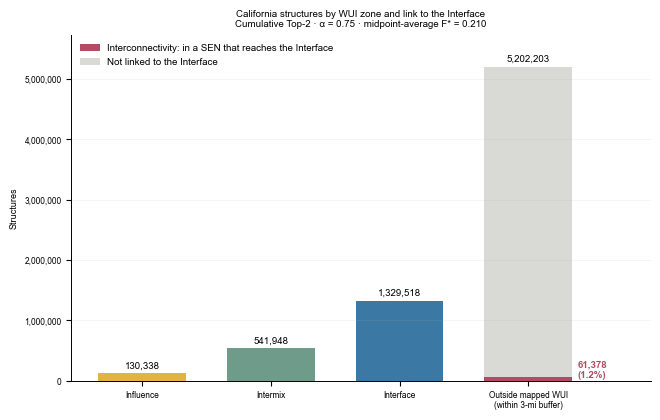

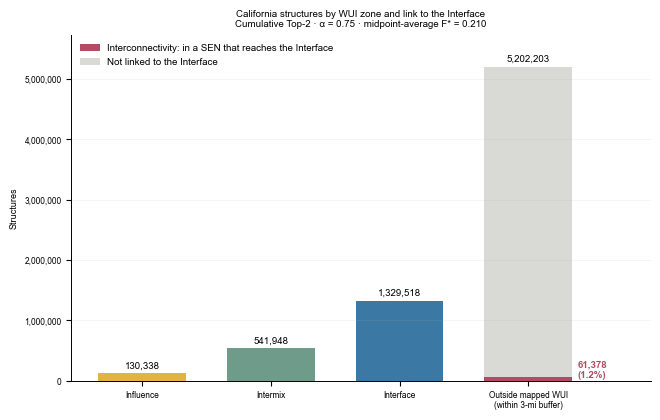

In [13]:
# Mutually exclusive statewide counts for the three mapped classes and
# CTop2 alpha=.75 Interconnectivity outside mapped WUI.
import shapely

WUI_CLASS_CACHE = DERIVED / 'california_building_wui_class.parquet'
if WUI_CLASS_CACHE.exists():
    building_wui = pd.read_parquet(WUI_CLASS_CACHE)
else:
    state_centroids = pd.read_parquet(STATE_CENTROIDS)
    class_labels = np.full(
        len(state_centroids), 'Outside mapped WUI', dtype=object,
    )
    # Later classes overwrite earlier ones to enforce the stated priority.
    for wui_name in ('Influence', 'Intermix', 'Interface'):
        class_geometry = wui_classes[wui_name].geometry.union_all()
        shapely.prepare(class_geometry)
        class_labels[shapely.intersects_xy(
            class_geometry,
            state_centroids.x.to_numpy(), state_centroids.y.to_numpy(),
        )] = wui_name
    building_wui = pd.DataFrame({
        'building_id': state_centroids.building_id.to_numpy(),
        'wui_class': class_labels,
    })
    building_wui.to_parquet(
        WUI_CLASS_CACHE, index=False, compression='zstd',
    )

assignments = pd.read_parquet(
    top2_paths['assignments'],
    columns=['building_id', 'component_id', 'component_size'],
).merge(building_wui, on='building_id', how='left', validate='one_to_one')
interface_component_ids = assignments.loc[
    assignments.wui_class.eq('Interface')
    & assignments.component_size.ge(2),
    'component_id',
].unique()
is_interconnectivity = (
    assignments.wui_class.eq('Outside mapped WUI')
    & assignments.component_size.ge(2)
    & assignments.component_id.isin(interface_component_ids)
)

ZONE_ORDER = ['Influence', 'Intermix', 'Interface', 'Interconnectivity']
outside = assignments.wui_class.eq('Outside mapped WUI')
interconnected, outside_total = int(is_interconnectivity.sum()), int(outside.sum())
zone_counts = pd.DataFrame({
    'zone': ['Influence', 'Intermix', 'Interface',
             'Outside mapped WUI (within 3-mi buffer)', 'of which Interconnectivity'],
    'structures': [
        int(assignments.wui_class.eq('Influence').sum()),
        int(assignments.wui_class.eq('Intermix').sum()),
        int(assignments.wui_class.eq('Interface').sum()),
        outside_total, interconnected,
    ],
})
zone_counts['share_of_statewide_sample'] = (
    zone_counts.structures / len(assignments)
)
zone_counts['share_of_outside_mapped_wui'] = np.where(
    zone_counts.zone.str.startswith(('Outside', 'of which')),
    zone_counts.structures / outside_total, np.nan,
)
zone_counts['F_ij_threshold'] = F_2D_NETWORK_THRESHOLD
zone_counts['edge_floor_alpha'] = TOP2_EDGE_FLOOR_ALPHA
zone_counts.to_csv(
    RESULTS / 'california_structure_counts_by_wui_and_interconnectivity_ctop2_alpha075_p50.csv',
    index=False,
)

# Mapped classes as plain bars; everything outside them, stacked by whether
# its SEN reaches the Interface (Interconnectivity, highlighted) or not.
zone_colors = ['#E3B341', '#6F9B8A', '#3B78A3', '#B24C63']
UNLINKED_COLOR = '#D9D9D6'
bar_labels = ['Influence', 'Intermix', 'Interface', 'Outside mapped WUI\n(within 3-mi buffer)']
bar_totals = [*zone_counts.structures.iloc[:3], outside_total]
fig_z, ax_z = plt.subplots(figsize=(6.6, 4.2))
ax_z.bar(bar_labels[:3], bar_totals[:3], color=zone_colors[:3], width=.68, edgecolor='none')
ax_z.bar(bar_labels[3], interconnected, color=zone_colors[3], width=.68, edgecolor='none',
         label='Interconnectivity: in a SEN that reaches the Interface')
ax_z.bar(bar_labels[3], outside_total - interconnected, bottom=interconnected,
         color=UNLINKED_COLOR, width=.68, edgecolor='none',
         label='Not linked to the Interface')
for position, total in enumerate(bar_totals):
    ax_z.text(position, total + .01 * outside_total, f'{total:,}',
              ha='center', va='bottom', fontsize=7)
ax_z.text(3.38, interconnected / 2, f'{interconnected:,}\n({interconnected / outside_total:.1%})',
          ha='left', va='bottom', fontsize=7, color=zone_colors[3], fontweight='bold')
ax_z.set(
    xlim=(-.55, 3.95), ylabel='Structures',
    title='California structures by WUI zone and link to the Interface\n'
          f'Cumulative Top-2 · α = 0.75 · midpoint-average F* = {F_2D_NETWORK_THRESHOLD:.3f}',
)
ax_z.set_ylim(0, outside_total * 1.1)
ax_z.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:,.0f}'))
ax_z.grid(axis='y', alpha=.18, linewidth=.5)
ax_z.spines[['top', 'right']].set_visible(False)
ax_z.legend(frameon=False, fontsize=7, loc='upper left')
fig_z.tight_layout()
zone_stem = FIGURES / 'carsen_california_wui_interconnectivity_counts_ctop2_alpha075_p50'
fig_z.savefig(zone_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig_z.savefig(zone_stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white')
display(zone_counts)
print('saved', zone_stem.with_suffix('.png'))
fig_z


## Network-size bins by fire-hazard severity and WUI zone

The statewide WUI25 parquet supplies the mapped WUI class but not a severity attribute: `gridcode` encodes Intermix, Influence, Not WUI, and Interface. Fire-hazard severity is therefore joined independently from CAL FIRE's matching official 2024 SRA and 2025 LRA Fire Hazard Severity Zone layers. Each structure is counted by the size of its full statewide cumulative Top-2 SEN ($\alpha=0.75$, midpoint-average $F^*_{2D}=0.2104$). Panel b shows the three mapped-WUI classes, every structure outside them within the three-mile buffer, and, beside it, Interconnectivity, the subset of those outside structures whose SEN reaches the Interface. The tables report both structures and distinct SENs represented in each cell; a SEN may be represented in more than one severity or WUI class.

,severity,network_size_bin,building_count,sen_count,share_within_class
0,Not classified,1,29970,29970,0.544365
1,Not classified,2–4,13957,5802,0.253510
2,Not classified,5–9,5765,968,0.104713
3,Not classified,10–24,3564,302,0.064735
4,Not classified,25–99,1799,58,0.032676
5,Not classified,100–499,0,0,0.000000
6,Not classified,500+,0,0,0.000000
7,NonWildland,1,1008913,1008913,0.199409
8,NonWildland,2–4,1525525,592244,0.301517
9,NonWildland,5–9,1115018,176890,0.220381


,analysis_zone,network_size_bin,building_count,sen_count,share_within_class
0,Influence,1,84357,84357,0.647217
1,Influence,2–4,25774,11060,0.197747
2,Influence,5–9,10445,1919,0.080138
3,Influence,10–24,8044,807,0.061716
4,Influence,25–99,1701,99,0.013051
5,Influence,100–499,17,2,0.000130
6,Influence,500+,0,0,0.000000
7,Intermix,1,324518,324518,0.598799
8,Intermix,2–4,144762,63011,0.267114
9,Intermix,5–9,43607,8065,0.080463


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_network_size_bins_fhsz_wui_ctop2_alpha075_p50.png


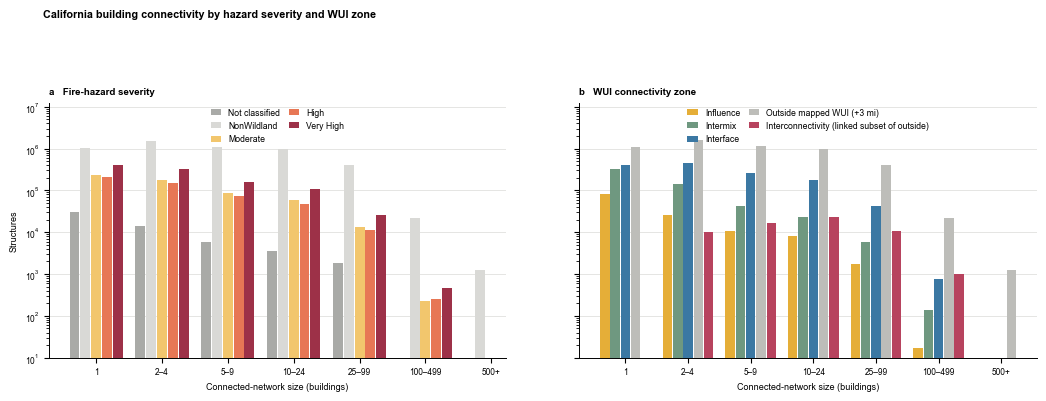

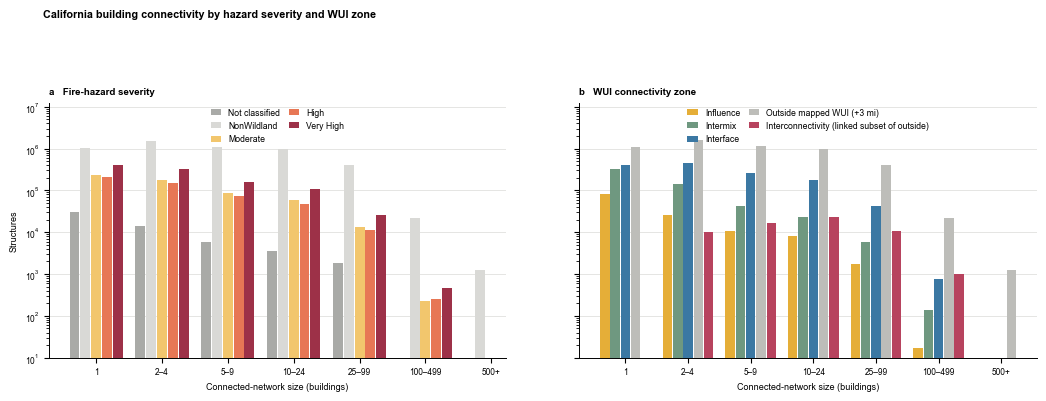

In [14]:
from concurrent.futures import ThreadPoolExecutor
import pyarrow.parquet as pq
import requests

CA_WUI25_SOURCE = Path(os.environ.get(
    'CALFIRE_CA_WUI25_PARQUET',
    '/Users/adamswietek/Documents/PostDoc/data/raw_la/fire/'
    '20260728T155639Z_b866/part-00000.parquet',
))
FHSZ_POLYGON_CACHE = DERIVED / 'california_fhsz_2024_2025.parquet'
FHSZ_BUILDING_CACHE = DERIVED / 'california_building_fhsz_2024_2025.parquet'
FHSZ_SERVICES = {
    'LRA': (
        'https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/'
        'services/FHSALRA25_v1_All/FeatureServer/0/query'
    ),
    'SRA': (
        'https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/'
        'services/FHSZSRA_23_3/FeatureServer/0/query'
    ),
}

if CA_WUI25_SOURCE.exists():
    wui25_schema = set(pq.ParquetFile(CA_WUI25_SOURCE).schema_arrow.names)
    assert {'gridcode', 'WUI_DESC', 'Shape'}.issubset(wui25_schema)
    assert not {'HAZ_NUM', 'HAZ_DESC'}.intersection(wui25_schema), (
        'The WUI25 source unexpectedly changed; review severity handling.'
    )

def _download_fhsz_service(jurisdiction, service_url):
    count_response = requests.get(
        service_url, params={
            'where': '1=1', 'returnCountOnly': 'true', 'f': 'json',
        }, timeout=180,
    )
    count_response.raise_for_status()
    count = int(count_response.json()['count'])

    def fetch_page(offset):
        response = requests.get(
            service_url, params={
                'where': '1=1',
                'outFields': 'FHSZ,FHSZ_Description',
                'returnGeometry': 'true',
                'outSR': '3310',
                'f': 'geojson',
                'resultOffset': offset,
                'resultRecordCount': 2000,
                'orderByFields': 'OBJECTID',
            }, timeout=240,
        )
        response.raise_for_status()
        return response.json().get('features', [])

    offsets = range(0, count, 2000)
    with ThreadPoolExecutor(max_workers=6) as executor:
        feature_pages = list(executor.map(fetch_page, offsets))
    features = [feature for page in feature_pages for feature in page]
    frame = gpd.GeoDataFrame.from_features(features, crs='EPSG:3310')
    frame['jurisdiction'] = jurisdiction
    return frame[['FHSZ', 'FHSZ_Description', 'jurisdiction', 'geometry']]

if FHSZ_POLYGON_CACHE.exists():
    fhsz = gpd.read_parquet(FHSZ_POLYGON_CACHE)
else:
    fhsz = gpd.GeoDataFrame(pd.concat([
        _download_fhsz_service(jurisdiction, service_url)
        for jurisdiction, service_url in FHSZ_SERVICES.items()
    ], ignore_index=True), geometry='geometry', crs='EPSG:3310')
    fhsz.to_parquet(FHSZ_POLYGON_CACHE, index=False, compression='zstd')

SEVERITY_ORDER = [
    'Not classified', 'NonWildland', 'Moderate', 'High', 'Very High',
]
if FHSZ_BUILDING_CACHE.exists():
    building_severity = pd.read_parquet(FHSZ_BUILDING_CACHE)
else:
    state_centroids = pd.read_parquet(STATE_CENTROIDS)
    severity_labels = np.full(
        len(state_centroids), 'Not classified', dtype=object,
    )
    for severity in SEVERITY_ORDER[1:]:
        severity_geometry = fhsz.loc[
            fhsz.FHSZ_Description.eq(severity), 'geometry'
        ].union_all()
        shapely.prepare(severity_geometry)
        severity_labels[shapely.intersects_xy(
            severity_geometry,
            state_centroids.x.to_numpy(), state_centroids.y.to_numpy(),
        )] = severity
    building_severity = pd.DataFrame({
        'building_id': state_centroids.building_id.to_numpy(),
        'severity': severity_labels,
    })
    building_severity.to_parquet(
        FHSZ_BUILDING_CACHE, index=False, compression='zstd',
    )

network_bins = [1, 2, 5, 10, 25, 100, 500, np.inf]
NETWORK_BIN_ORDER = [
    '1', '2–4', '5–9', '10–24', '25–99', '100–499', '500+',
]
# Zone per structure: its mapped-WUI class, or Interconnectivity outside them.
assignments['analysis_zone'] = assignments.wui_class.where(
    assignments.wui_class.isin(ZONE_ORDER[:-1])
)
assignments.loc[is_interconnectivity, 'analysis_zone'] = 'Interconnectivity'
network_classified = assignments.merge(
    building_severity, on='building_id', how='left', validate='one_to_one',
)
network_classified['network_size_bin'] = pd.cut(
    network_classified.component_size, bins=network_bins, right=False,
    labels=NETWORK_BIN_ORDER, ordered=True,
)
network_classified['severity'] = pd.Categorical(
    network_classified.severity.fillna('Not classified'),
    categories=SEVERITY_ORDER, ordered=True,
)
network_classified['analysis_zone'] = pd.Categorical(
    network_classified.analysis_zone, categories=ZONE_ORDER, ordered=True,
)

def binned_counts(frame, class_column, class_order):
    complete_index = pd.MultiIndex.from_product(
        [class_order, NETWORK_BIN_ORDER],
        names=[class_column, 'network_size_bin'],
    )
    summary = (
        frame.groupby([class_column, 'network_size_bin'], observed=True)
        .agg(
            building_count=('building_id', 'size'),
            sen_count=('component_id', 'nunique'),
        )
        .reindex(complete_index, fill_value=0)
        .reset_index()
    )
    totals = summary.groupby(class_column).building_count.transform('sum')
    summary['share_within_class'] = np.divide(
        summary.building_count, totals,
        out=np.zeros(len(summary), dtype=float), where=totals.gt(0),
    )
    return summary

severity_bin_counts = binned_counts(
    network_classified, 'severity', SEVERITY_ORDER,
)
zone_bin_counts = binned_counts(
    network_classified.dropna(subset=['analysis_zone']),
    'analysis_zone', ZONE_ORDER,
)
# Panel b also counts every structure outside the mapped WUI (within the 3-mi
# buffer); Interconnectivity is the subset of those linked to the Interface.
OUTSIDE_ZONE = 'Outside mapped WUI (+3 mi)'
PANEL_B_ORDER = [*ZONE_ORDER[:-1], OUTSIDE_ZONE, ZONE_ORDER[-1]]
zone_bin_counts = pd.concat([
    zone_bin_counts,
    binned_counts(
        network_classified.loc[network_classified.wui_class.eq('Outside mapped WUI')]
        .assign(analysis_zone=OUTSIDE_ZONE),
        'analysis_zone', [OUTSIDE_ZONE],
    ),
], ignore_index=True)
severity_bin_counts.to_csv(
    RESULTS / 'california_network_size_bins_by_fhsz_ctop2_alpha075_p50.csv',
    index=False,
)
zone_bin_counts.to_csv(
    RESULTS / 'california_network_size_bins_by_wui_zone_ctop2_alpha075_p50.csv',
    index=False,
)

SEVERITY_COLORS = {
    'Not classified': '#A9AAA7',
    'NonWildland': '#D9D9D6',
    'Moderate': '#F2C66D',
    'High': '#E77755',
    'Very High': '#9D3148',
}
ZONE_COLORS = {
    'Influence': '#E5AE38',
    'Intermix': '#6F9880',
    'Interface': '#3B78A3',
    OUTSIDE_ZONE: '#BDBDB9',
    'Interconnectivity': '#B7435E',
}
ZONE_LABELS = {'Interconnectivity': 'Interconnectivity (linked subset of outside)'}

def grouped_count_bars(ax, summary, class_column, class_order, colors, labels=None):
    x = np.arange(len(NETWORK_BIN_ORDER))
    group_width = .82
    bar_width = group_width / len(class_order)
    for index, category in enumerate(class_order):
        values = (summary.loc[summary[class_column].eq(category)]
                  .set_index('network_size_bin')
                  .reindex(NETWORK_BIN_ORDER).building_count
                  .fillna(0).to_numpy())
        positions = x - group_width / 2 + bar_width * (index + .5)
        ax.bar(
            positions, np.where(values > 0, values, np.nan),
            width=bar_width * .92, color=colors[category],
            label=(labels or {}).get(category, category), linewidth=0, rasterized=True,
        )
    ax.set_xticks(x, NETWORK_BIN_ORDER)
    ax.set_yscale('log')
    ax.set_ylim(10, 4_000_000)
    ax.set_xlabel('Connected-network size (buildings)')
    ax.grid(axis='y', which='major', color='#D7D7D3', linewidth=.45)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

fig_h, axes_h = plt.subplots(1, 2, figsize=(10.8, 4.25), sharey=True)
grouped_count_bars(
    axes_h[0], severity_bin_counts, 'severity',
    SEVERITY_ORDER, SEVERITY_COLORS,
)
grouped_count_bars(
    axes_h[1], zone_bin_counts, 'analysis_zone',
    PANEL_B_ORDER, ZONE_COLORS, labels=ZONE_LABELS,
)
# Headroom so the legends clear the tallest bars (the axes share y).
axes_h[0].set_ylim(10, 8 * max(
    severity_bin_counts.building_count.max(), zone_bin_counts.building_count.max()))
axes_h[0].set_title('a   Fire-hazard severity', loc='left', fontweight='bold')
axes_h[1].set_title('b   WUI connectivity zone', loc='left', fontweight='bold')
axes_h[0].set_ylabel('Structures')
axes_h[0].legend(
    loc='upper center', bbox_to_anchor=(.5, 1.01),
    frameon=False, ncol=2, columnspacing=1.0, handlelength=1.2,
)
axes_h[1].legend(
    loc='upper center', bbox_to_anchor=(.5, 1.01),
    frameon=False, ncol=2, columnspacing=1.0, handlelength=1.2,
)
fig_h.suptitle(
    'California building connectivity by hazard severity and WUI zone',
    x=.07, ha='left', fontweight='bold',
)
fig_h.subplots_adjust(left=.075, right=.99, top=.76, bottom=.16, wspace=.16)
hazard_stem = (
    FIGURES / 'carsen_california_network_size_bins_fhsz_wui_ctop2_alpha075_p50'
)
fig_h.savefig(hazard_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white')
fig_h.savefig(hazard_stem.with_suffix('.png'), dpi=600, bbox_inches='tight', facecolor='white')
display(severity_bin_counts)
display(zone_bin_counts)
print('saved', hazard_stem.with_suffix('.png'))
fig_h


,major_region,minimum_sen_size,structures_in_large_sens,sens_represented,largest_sen,high_or_very_high_structures,share_of_high_or_very_high_structures
0,Southern California,10,169626,12190,165,990703,0.1712
1,Central California,10,9481,732,84,153611,0.0617
2,Northern California,10,15058,1255,79,372861,0.0404
3,Southern California,25,34371,1250,165,990703,0.0347
4,Central California,25,1839,69,84,153611,0.0120
5,Northern California,25,1782,75,79,372861,0.0048


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/carsen_california_high_very_high_fhsz_large_sens_by_major_region_ctop2_alpha075_p50.png


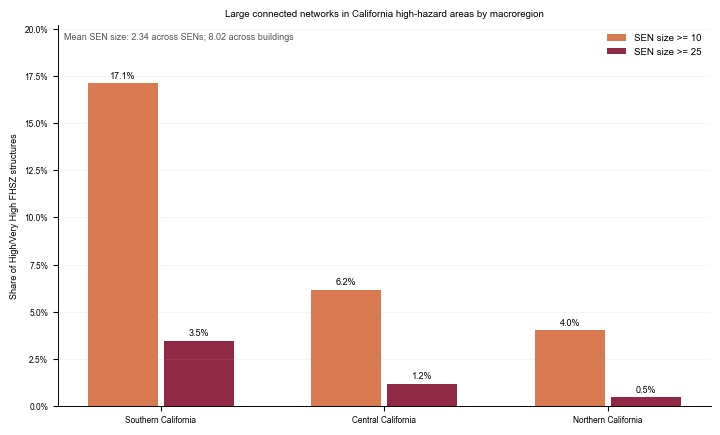

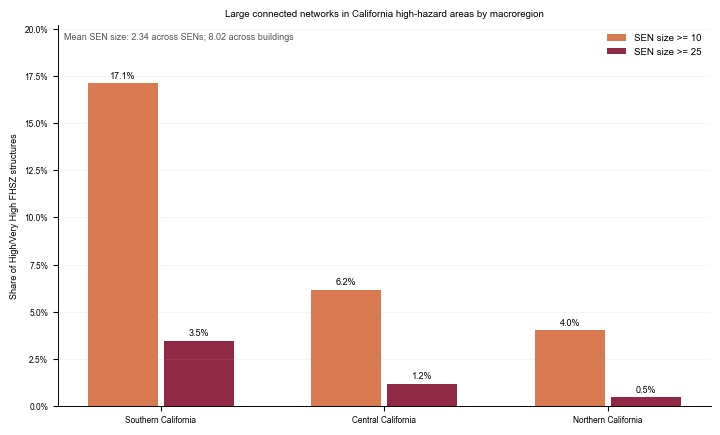

In [15]:
# High/Very High FHSZ structures in larger-than-average SENs, by macroregion.
# These transparent latitude bands are descriptive, not administrative regions:
# Southern < 35.0°N; Central 35.0–37.5°N; Northern >= 37.5°N.
from matplotlib.ticker import PercentFormatter
from pyproj import Transformer

REGION_ORDER = ['Southern California', 'Central California', 'Northern California']
LARGE_SEN_THRESHOLDS = [10, 25]

high_hazard = network_classified.loc[
    network_classified.severity.isin(['High', 'Very High']),
    ['building_id', 'component_id', 'component_size'],
].merge(
    pd.read_parquet(STATE_CENTROIDS, columns=['building_id', 'x', 'y']),
    on='building_id', how='left', validate='one_to_one',
)
to_wgs84 = Transformer.from_crs(3310, 4326, always_xy=True)
_, high_hazard['latitude'] = to_wgs84.transform(
    high_hazard.x.to_numpy(), high_hazard.y.to_numpy(),
)
high_hazard['major_region'] = pd.cut(
    high_hazard.latitude, bins=[-np.inf, 35.0, 37.5, np.inf],
    labels=REGION_ORDER, right=False, ordered=True,
)

region_denominators = (
    high_hazard.groupby('major_region', observed=False)
    .size().rename('high_or_very_high_structures')
)
regional_large_sen_rows = []
for threshold in LARGE_SEN_THRESHOLDS:
    qualifying = high_hazard.loc[high_hazard.component_size.ge(threshold)]
    summary = (
        qualifying.groupby('major_region', observed=False)
        .agg(
            structures_in_large_sens=('building_id', 'size'),
            sens_represented=('component_id', 'nunique'),
            largest_sen=('component_size', 'max'),
        )
        .join(region_denominators).reset_index()
    )
    summary.insert(1, 'minimum_sen_size', threshold)
    summary['share_of_high_or_very_high_structures'] = (
        summary.structures_in_large_sens
        / summary.high_or_very_high_structures
    )
    regional_large_sen_rows.append(summary)
regional_high_hazard_large_sens = pd.concat(
    regional_large_sen_rows, ignore_index=True,
)
regional_high_hazard_large_sens.to_csv(
    RESULTS / 'california_high_very_high_fhsz_large_sens_by_major_region_ctop2_alpha075_p50.csv',
    index=False,
)

distinct_sens = network_classified[[
    'component_id', 'component_size',
]].drop_duplicates('component_id')
mean_sen_size = distinct_sens.component_size.mean()
building_weighted_mean_sen_size = network_classified.component_size.mean()

fig_r, ax_r = plt.subplots(figsize=(7.2, 4.35))
x = np.arange(len(REGION_ORDER))
width = .34
threshold_colors = ['#D97952', '#8F2945']
for index, (threshold, color) in enumerate(zip(
    LARGE_SEN_THRESHOLDS, threshold_colors,
)):
    plot_rows = (
        regional_high_hazard_large_sens.loc[
            regional_high_hazard_large_sens.minimum_sen_size.eq(threshold)
        ].set_index('major_region').reindex(REGION_ORDER)
    )
    positions = x + (index - .5) * width
    bars = ax_r.bar(
        positions, plot_rows.share_of_high_or_very_high_structures,
        width=width * .92, color=color, label=f'SEN size >= {threshold}',
    )
    ax_r.bar_label(
        bars, labels=[f'{value:.1%}' for value in bars.datavalues],
        padding=2, fontsize=6.5,
    )
ax_r.set(
    xticks=x, xticklabels=REGION_ORDER,
    ylabel='Share of High/Very High FHSZ structures',
    title='Large connected networks in California high-hazard areas by macroregion',
)
ax_r.yaxis.set_major_formatter(PercentFormatter(1))
ax_r.set_ylim(0, max(
    .01, regional_high_hazard_large_sens.share_of_high_or_very_high_structures.max() * 1.18,
))
ax_r.grid(axis='y', alpha=.18, linewidth=.5)
ax_r.spines[['top', 'right']].set_visible(False)
ax_r.legend(frameon=False, fontsize=7)
ax_r.text(
    .01, .98,
    f'Mean SEN size: {mean_sen_size:.2f} across SENs; '
    f'{building_weighted_mean_sen_size:.2f} across buildings',
    transform=ax_r.transAxes, ha='left', va='top', fontsize=6.5, color='#555555',
)
fig_r.tight_layout()
regional_hazard_stem = (
    FIGURES / 'carsen_california_high_very_high_fhsz_large_sens_by_major_region_ctop2_alpha075_p50'
)
fig_r.savefig(
    regional_hazard_stem.with_suffix('.pdf'), bbox_inches='tight', facecolor='white',
)
fig_r.savefig(
    regional_hazard_stem.with_suffix('.png'), dpi=600,
    bbox_inches='tight', facecolor='white',
)
display(regional_high_hazard_large_sens.round({
    'share_of_high_or_very_high_structures': 4,
}))
print('saved', regional_hazard_stem.with_suffix('.png'))
fig_r


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/california_wui_all_3mi_osm_2d/Fig6_california_connectivity_hazard_wui_ctop2_alpha075_midpoint_average.png
main Figure 6 /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main/Fig6_california_connectivity_hazard_wui_ctop2_alpha075_p50.png


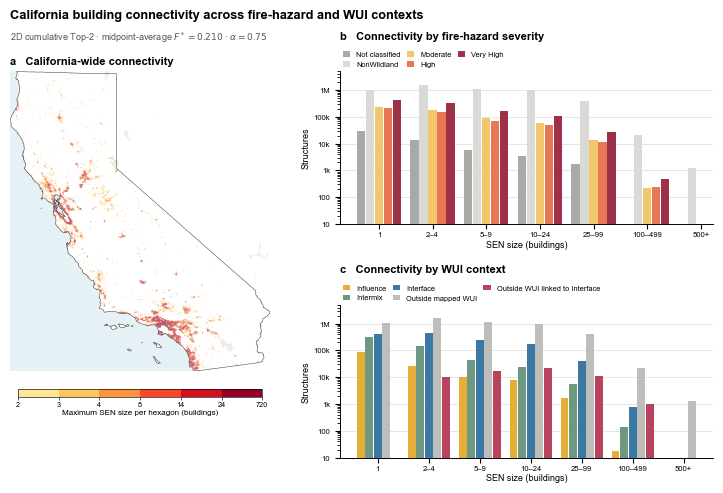

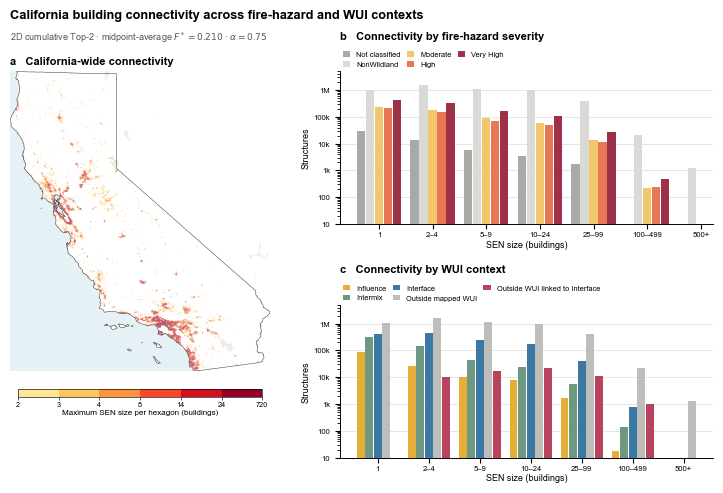

In [16]:
from src.viz.carsen_publication import (
    plot_california_connectivity_context, save_png_as_pdf,
)
from src.figure_paths import save_figure as save_to_tier

fig_publication = plot_california_connectivity_context(
    clusters=clusters,
    state_boundary=state_boundary,
    state_ocean=state_ocean,
    state_lakes=state_lakes,
    water_color=WATER_COLOR,
    outline_color=STATE_OUTLINE_COLOR,
    network_cmap=network_cmap,
    network_norm=network_norm,
    network_bounds=NETWORK_BOUNDS,
    gridsize_from_extent=gridsize_from_extent,
    severity_counts=severity_bin_counts,
    severity_order=SEVERITY_ORDER,
    severity_colors=SEVERITY_COLORS,
    zone_counts=zone_bin_counts,
    zone_order=PANEL_B_ORDER,
    zone_colors=ZONE_COLORS,
    outside_zone=OUTSIDE_ZONE,
    network_bin_order=NETWORK_BIN_ORDER,
    threshold=F_2D_NETWORK_THRESHOLD,
    alpha=TOP2_EDGE_FLOOR_ALPHA,
)
publication_stem = (
    FIGURES / 'Fig6_california_connectivity_hazard_wui_'
    'ctop2_alpha075_midpoint_average'
)
for suffix, kwargs in (
    ('.svg', {}),
    ('.png', {'dpi': 600}),
):
    fig_publication.savefig(
        publication_stem.with_suffix(suffix),
        bbox_inches='tight', pad_inches=.025, facecolor='white', **kwargs,
    )
save_png_as_pdf(
    publication_stem.with_suffix('.png'),
    publication_stem.with_suffix('.pdf'),
)
main_stem = save_to_tier(
    fig_publication,
    'Fig6_california_connectivity_hazard_wui_ctop2_alpha075_p50',
    'main', dpi=600, pad_inches=.025,
)
fig_publication.savefig(
    main_stem.with_suffix('.svg'), bbox_inches='tight',
    pad_inches=.025, facecolor='white',
)
save_png_as_pdf(
    main_stem.with_suffix('.png'), main_stem.with_suffix('.pdf'),
)
print('saved', publication_stem.with_suffix('.png'))
print('main Figure 6', main_stem.with_suffix('.png'))
fig_publication